# Cryptocurrency Portfolio Optimisation: A GARCH-EVT Forecasted CVaR constraint and Safe Reinforcement Learning Approach

This is the main jupyter notebook for my Bachelor Degree Dissertaion in University of Southampton. This note book is relied on the [FinRL](https://github.com/AI4Finance-Foundation/FinRL), which is also modified by me to better suit my research.

## Table of Contents

* [1. Problem Definition](#1)
* [2. Getting Started - Load Python packages](#2)
    * [2.1. Install Packages](#2.1)
    * [2.2. Import Packages](#2.2)
    * [2.3. Create Folders](#2.3)
* [3. Download Data](#3)
* [4. Preprocess Data](#4)
* [5.Build Environment](#5) 
* [6.Implement DRL Algorithms](#6)
* [7.Backtesting Performance](#7)

<a id='1'></a>
# Part 1. Problem Definition

This study leverages **GARCH(1,1) to predict future volatility** and computes the **forecasted Conditional Value at Risk (Forecasted CVaR, $ \widehat{\text{CVaR}} $)**, which is then integrated into a safe reinforcement learning (RL) framework for portfolio optimization. The entire problem is formulated as a **Markov Decision Process (MDP)** as follows:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)
$$

where:
- **$ \mathcal{S} $** is the state space.
- **$ \mathcal{A} $** is the action space.
- **$ \mathcal{P} $** is the state transition function.
- **$ \mathcal{R} $** is the reward function.
- **$ \gamma $** is the discount factor.

**1. State Space ($ \mathcal{S} $)**

At time $ t $, the portfolio state is defined as:

$$
s_t = \{ P_t, O_t, H_t, L_t, C_t, V_t, W_t, I_t, M_t, \widehat{\text{CVaR}}_t \}
$$

where:
- **Price Information**:
  - $ O_t = (o_t^1, o_t^2, ..., o_t^n) $: Opening prices of all assets.
  - $ H_t = (h_t^1, h_t^2, ..., h_t^n) $: High prices of all assets.
  - $ L_t = (l_t^1, l_t^2, ..., l_t^n) $: Low prices of all assets.
  - $ C_t = (c_t^1, c_t^2, ..., c_t^n) $: Closing prices of all assets.
  - $ V_t = (v_t^1, v_t^2, ..., v_t^n) $: Volume of all assets.
- **Current Portfolio Holdings**:
  - $ W_t = (w_t^1, w_t^2, ..., w_t^n) $: Current asset allocations, satisfying $ \sum_{i=1}^{n} w_t^i = 1 $.
- **Market Trading Status**:
  - $ I_t = (i_t^1, i_t^2, ..., i_t^n) $: Indicator variables denoting whether an asset is tradable (e.g., stocks are not tradable on weekends).
- **Market Technical Indicators**:
  - $ M_t $: Includes **MACD**, **RSI**, **moving averages (MA)**, etc.
- **Forecasted CVaR**:
  - Future **CVaR** calculated using **GARCH-predicted volatility**:
    $$
    \widehat{\text{CVaR}}_t = -\left(\Phi^{-1}(\alpha) + \frac{\phi(\Phi^{-1}(\alpha))}{1 - \alpha} \right) \cdot \widehat{\sigma}_{t+1}
    $$

**2. Action Space ($ \mathcal{A} $)**

Portfolio adjustments are made by modifying asset weights $ W_t $:

$$
a_t = (a_t^1, a_t^2, ..., a_t^n) \quad \text{where } \sum_{i=1}^{n} a_t^i = 1
$$

However, actions must pass through a **safety layer (Safety Layer)**, ensuring:
1. **Weight Bound Constraints**:
   $$
   0 \leq w_t^i \leq 1, \quad \forall i
   $$
2. **Cardinality Constraint**:
   $$
   \sum_{i=1}^{n} \mathbf{1}(w_t^i > 0) \leq K
   $$
   where $ K $ is the maximum number of selected assets.
3. **Non-Tradable Days Constraint**:
   $$
   a_t^i = w_t^i, \quad \text{if } I_t^i = 0
   $$
   ensuring that non-crypto assets cannot be adjusted on non-trading days.

The **safety layer** then applies a projection operator $ \Pi $:

$$
\tilde{a}_t = \Pi(a_t)
$$

**3. State Transition ($ \mathcal{P} $)**

Portfolio value $ P_t $ evolves based on asset price movements:

$$
P_{t+1} = P_t \sum_{i=1}^{n} w_t^i \frac{C_{t+1}^i}{C_t^i}
$$

If an asset is not tradable on a particular day, its price remains unchanged:

$$
C_{t+1}^i = C_t^i, \quad \text{if } I_t^i = 0
$$

GARCH-predicted future volatility follows the transition equation:

$$
\widehat{\sigma}_{t+1}^2 = \omega + \alpha \cdot r_t^2 + \beta \cdot \sigma_t^2
$$

**4. Reward Function ($ \mathcal{R} $)**

The reward function considers **portfolio returns, forecasted CVaR risk, and transaction costs**:

$$
R_t = P_{t+1} - \lambda \cdot \widehat{\text{CVaR}}_t - \delta_t
$$

where:
- **Portfolio Return**:
  $$
  P_{t+1} = P_t \sum_{i=1}^{n} w_t^i \frac{C_{t+1}^i}{C_t^i}
  $$
- **GARCH-Predicted Future CVaR**:
  $$
  \widehat{\text{CVaR}}_{\alpha} = -\left(\Phi^{-1}(\alpha) + \frac{\phi(\Phi^{-1}(\alpha))}{1 - \alpha} \right) \cdot \widehat{\sigma}_{t+1}
  $$
- **Transaction Costs**:
  $$
  \delta_t = \sum_{i=1}^{n} |w_t^i - w_{t-1}^i| \cdot \beta_i \cdot P_t
  $$
  where $ \beta_i $ represents the transaction cost coefficient for each asset.

**5. Discount Factor ($ \gamma $)**

To account for long-term returns, we introduce a discount factor $ \gamma \in (0,1) $:

$$
G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k}
$$

**Summary**

This study leverages **GARCH to predict future volatility and compute Forecasted CVaR**, which is integrated into a reinforcement learning-based portfolio optimization framework:
1. **Uses Forecasted CVaR to optimize risk-adjusted returns**, overcoming limitations of static CVaR.
2. **Incorporates a safety layer** to ensure realistic trading constraints.
3. **Considers market trading rules (e.g., stocks are non-tradable on weekends)** for enhanced real-world applicability.


<a id='2'></a>
# Part 2. Getting Started- Load Python Packages

<a id='2.1'></a>
## 2.1. Install Packages

See in requirement

<a id='2.2'></a>
## 2.2. Import Packages

In [1]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import os
from argparse import ArgumentParser
from typing import List
import copy
import datetime
from copy import deepcopy
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import pyfolio
from pyfolio import timeseries

import warnings
warnings.filterwarnings("ignore")

c:\Users\Jiang\anaconda3\envs\FinRL\Lib\site-packages\pyfolio\pos.py:26: UserWarning: Module "zipline.assets" not found; mutltipliers will not be applied to position notionals.
  warnings.warn(


<a id='2.3'></a>
## 2.3. Create Folders

In [2]:
import config
# !python ResetFolder.py
RECONSTRUCT = False
if RECONSTRUCT:
    if not os.path.exists("./" + config.DATA_SAVE_DIR):
        os.makedirs("./" + config.DATA_SAVE_DIR)
    if not os.path.exists("./" + config.TRAINED_MODEL_DIR):
        os.makedirs("./" + config.TRAINED_MODEL_DIR)
    if not os.path.exists("./" + config.TENSORBOARD_LOG_DIR):
        os.makedirs("./" + config.TENSORBOARD_LOG_DIR)
    if not os.path.exists("./" + config.RESULTS_DIR):
        os.makedirs("./" + config.RESULTS_DIR)

<a id='3'></a>
# Part 3. Download Data

In [3]:
from config_tickers import CRYPTO_TICKER, DOW_30_TICKER
from config import TRAIN_START_DATE, TRAIN_END_DATE, TEST_END_DATE, TEST_START_DATE
from lib.yahoodownloader import YahooDownloader

df = YahooDownloader(start_date = TRAIN_START_DATE,
                        end_date = TEST_END_DATE,
                        ticker_list = DOW_30_TICKER+CRYPTO_TICKER).fetch_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (85415, 8)


Max Return: 26.04% (CRM on 2020-08-26)
Min Return: -23.85% (BA on 2020-03-16)
Max Return: 355.55% (DOGE-USD on 2021-01-28)
Min Return: -42.35% (ETH-USD on 2020-03-12)


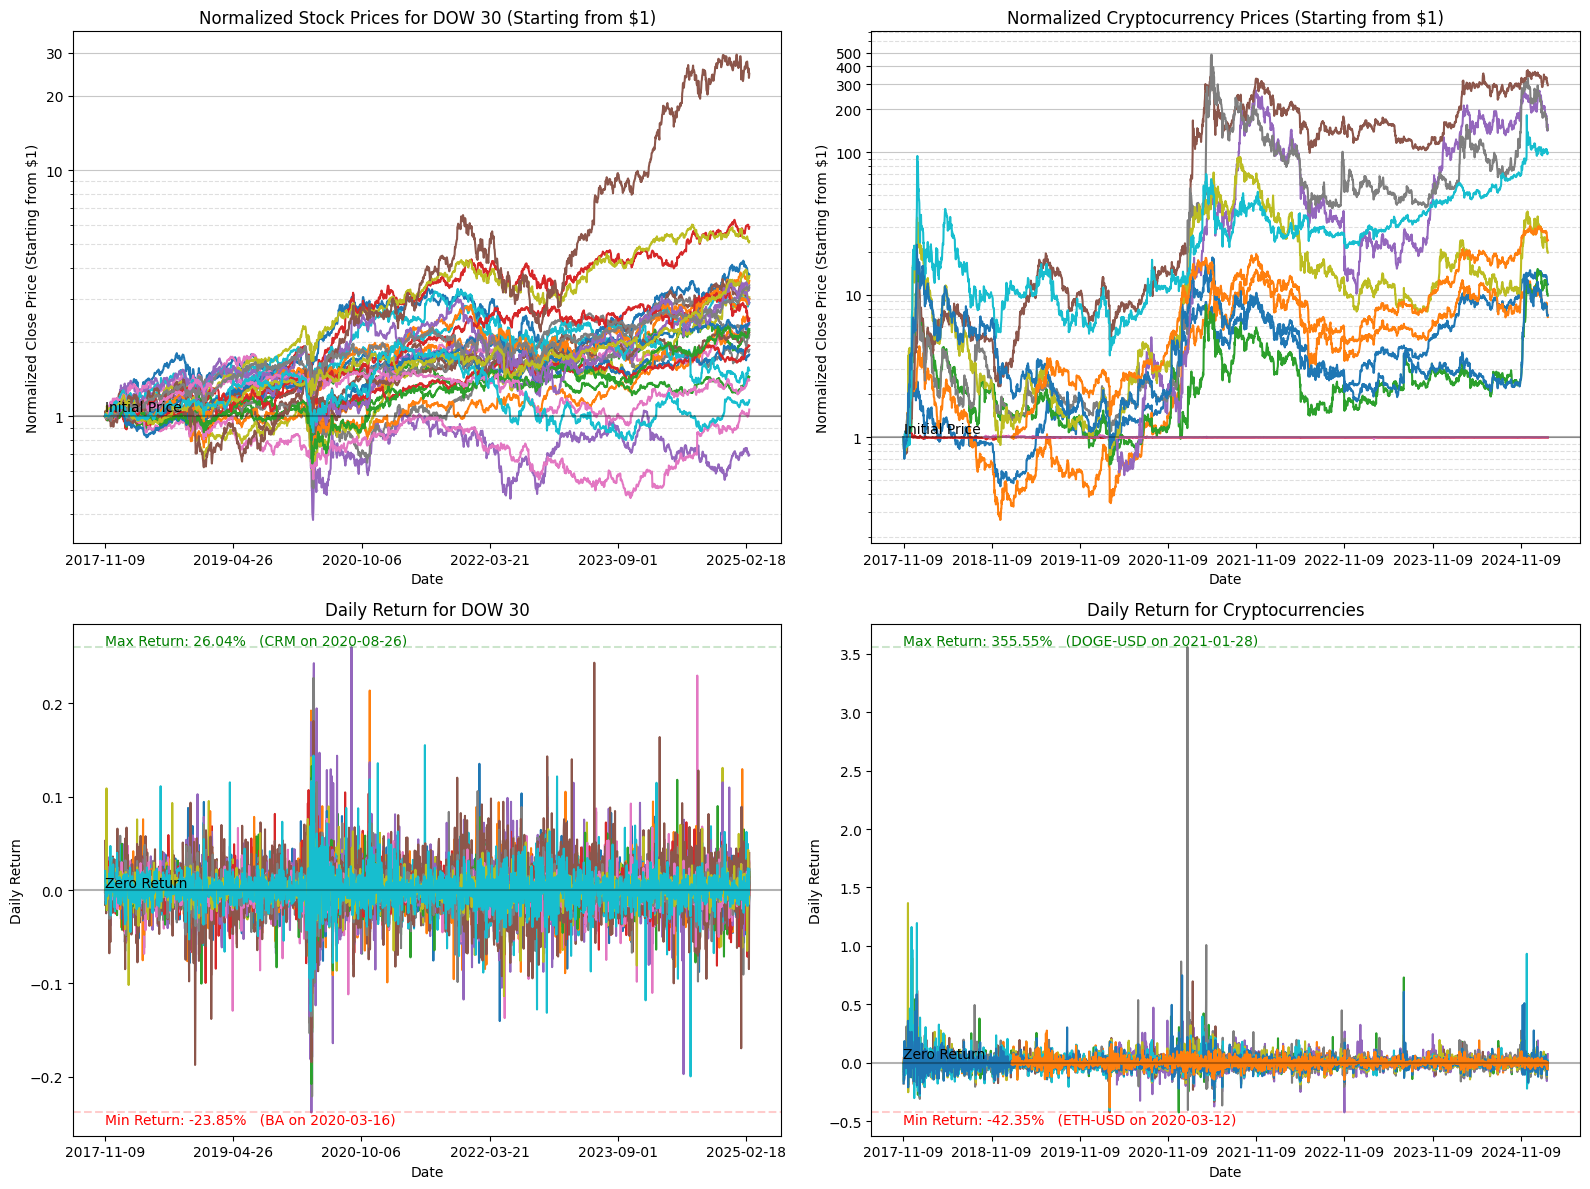

Price,date,close,high,low,open,volume,tic,day
0,2017-11-09,41.182472,44.025002,43.285000,43.777500,117930400,AAPL,3
1,2017-11-09,0.032053,0.035060,0.025006,0.025160,18716200,ADA-USD,3
2,2017-11-09,138.740662,174.229996,171.309998,172.750000,2005100,AMGN,3
3,2017-11-09,56.456501,56.480999,55.788502,56.298000,74654000,AMZN,3
4,2017-11-09,84.818520,94.660004,93.279999,94.339996,3949800,AXP,3
...,...,...,...,...,...,...,...,...
85410,2025-02-28,43.099998,43.759998,42.610001,43.430000,25197500,VZ,4
85411,2025-02-28,84194.656250,84608.523438,78451.554688,84591.273438,649418985,WBTC-USD,4
85412,2025-02-28,98.610001,98.860001,97.169998,97.790001,25451300,WMT,4
85413,2025-02-28,0.286358,0.287716,0.252873,0.283120,304286663,XLM-USD,4


In [4]:
from config_tickers import DOW_30_TICKER, CRYPTO_TICKER

# 计算每个股票的归一化价格（以1美元为基准）
df['normalized_close'] = df.groupby('tic')['close'].transform(lambda x: x / x.iloc[0])

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 绘制DOW_30_TICKER股票走势
for tic in DOW_30_TICKER:
    if tic in df['tic'].unique():
        axs[0, 0].plot(df[df['tic'] == tic]['date'], df[df['tic'] == tic]['normalized_close'], label=tic)

axs[0, 0].set_xlabel('Date')
axs[0, 0].set_ylabel('Normalized Close Price (Starting from $1)')
axs[0, 0].set_title('Normalized Stock Prices for DOW 30 (Starting from $1)')
#axs[0, 0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axs[0, 0].xaxis.set_major_locator(mdates.AutoDateLocator())
axs[0, 0].set_yscale('log')
axs[0, 0].set_yticks([1,10,20,30],labels=['1','10','20','30'])
axs[0, 0].grid(True, which='major', axis='y', linestyle='-', alpha=0.7)
axs[0, 0].grid(True, which='minor', axis='y', linestyle='--', alpha=0.4)
axs[0, 0].axhline(y=1.0, color='k', linestyle='-', alpha=0.3)
axs[0, 0].text(df['date'].min(), 1.02, 'Initial Price', verticalalignment='bottom', horizontalalignment='left', fontsize=10)

# 绘制CRYPTO_TICKER股票走势
for tic in CRYPTO_TICKER:
    if tic in df['tic'].unique():
        axs[0, 1].plot(df[df['tic'] == tic]['date'], df[df['tic'] == tic]['normalized_close'], label=tic)

axs[0, 1].set_xlabel('Date')
axs[0, 1].set_ylabel('Normalized Close Price (Starting from $1)')
axs[0, 1].set_title('Normalized Cryptocurrency Prices (Starting from $1)')
#axs[0, 1].legend(loc='upper left', bbox_to_anchor=(1, 1))
axs[0, 1].xaxis.set_major_locator(mdates.AutoDateLocator())
axs[0, 1].set_yscale('log')
axs[0, 1].set_yticks([1,10,100,200,300,400,500],labels=['1','10','100','200','300','400','500'])
axs[0, 1].grid(True, which='major', axis='y', linestyle='-', alpha=0.7)
axs[0, 1].grid(True, which='minor', axis='y', linestyle='--', alpha=0.4)
axs[0, 1].axhline(y=1.0, color='k', linestyle='-', alpha=0.3)
axs[0, 1].text(df['date'].min(), 1.02, 'Initial Price', verticalalignment='bottom', horizontalalignment='left', fontsize=10)

# 计算每个资产的每日增长率
df['daily_return'] = df.groupby('tic')['close'].pct_change()

# 绘制DOW_30_TICKER资产的增长率走势图
for tic in DOW_30_TICKER:
    if tic in df['tic'].unique():
        axs[1, 0].plot(df[df['tic'] == tic]['date'], df[df['tic'] == tic]['daily_return'], label=tic)

axs[1, 0].set_xlabel('Date')
axs[1, 0].set_ylabel('Daily Return')
axs[1, 0].set_title('Daily Return for DOW 30')
#axs[1, 0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axs[1, 0].xaxis.set_major_locator(mdates.AutoDateLocator())
axs[1, 0].set_yscale('linear')
axs[1, 0].axhline(y=0.0, color='k', linestyle='-', alpha=0.3)
axs[1, 0].text(df['date'].min(), 0.0002, 'Zero Return', verticalalignment='bottom', horizontalalignment='left', fontsize=10)

# 绘制CRYPTO_TICKER资产的增长率走势图
for tic in CRYPTO_TICKER:
    if tic in df['tic'].unique():
        axs[1, 1].plot(df[df['tic'] == tic]['date'], df[df['tic'] == tic]['daily_return'], label=tic)

axs[1, 1].set_xlabel('Date')
axs[1, 1].set_ylabel('Daily Return')
axs[1, 1].set_title('Daily Return for Cryptocurrencies')
#axs[1, 1].legend(loc='upper left', bbox_to_anchor=(1, 1))
axs[1, 1].xaxis.set_major_locator(mdates.AutoDateLocator())
axs[1, 1].set_yscale('linear')
axs[1, 1].axhline(y=0.0, color='k', linestyle='-', alpha=0.3)
axs[1, 1].text(df['date'].min(), 0.02, 'Zero Return', verticalalignment='bottom', horizontalalignment='left', fontsize=10)
# 标注最高return和最低return
for ax, ticker_list in zip([axs[1, 0], axs[1, 1]], [DOW_30_TICKER, CRYPTO_TICKER]):
    max_return_row = df[df['tic'].isin(ticker_list)].loc[df[df['tic'].isin(ticker_list)]['daily_return'].idxmax()]
    min_return_row = df[df['tic'].isin(ticker_list)].loc[df[df['tic'].isin(ticker_list)]['daily_return'].idxmin()]
    max_return = max_return_row['daily_return']
    min_return = min_return_row['daily_return']
    max_return_tic = max_return_row['tic']
    min_return_tic = min_return_row['tic']
    max_return_date = max_return_row['date']
    min_return_date = min_return_row['date']
    
    print(f'Max Return: {max_return:.2%} ({max_return_tic} on {max_return_date})')
    print(f'Min Return: {min_return:.2%} ({min_return_tic} on {min_return_date})')
    
    ax.axhline(y=max_return, color='g', linestyle='--', alpha=0.2)
    ax.text(df['date'].min(), max_return, f'Max Return: {max_return:.2%}   ({max_return_tic} on {max_return_date})', 
            verticalalignment='bottom', horizontalalignment='left', fontsize=10, color='g')
    
    ax.axhline(y=min_return, color='r', linestyle='--', alpha=0.2)
    ax.text(df['date'].min(), min_return, f'Min Return: {min_return:.2%}   ({min_return_tic} on {min_return_date})', 
            verticalalignment='top', horizontalalignment='left', fontsize=10, color='r')

plt.tight_layout()
plt.show()
df.drop(['normalized_close', 'daily_return'], axis=1, inplace=True)
df

<a id='4'></a>
# Part 4. Preprocess Data

Data preprocessing is a crucial step for training a high quality machine learning model. We need to check for missing data and do feature engineering in order to convert the data into a model-ready state.
* Add technical indicators. In practical trading, various information needs to be taken into account, for example the historical stock prices, current holding shares, technical indicators, etc. In this article, we demonstrate two trend-following technical indicators: "macd","boll_ub","boll_lb","rsi_30","cci_30","dx_30","close_30_sma","close_60_sma"
* Add turbulence index. Risk-aversion reflects whether an investor will choose to preserve the capital. It also influences one's trading strategy when facing different market volatility level. To control the risk in a worst-case scenario, such as financial crisis of 2007–2008, FinRL employs the financial turbulence index that measures extreme asset price fluctuation.

In [5]:
def clean_data(df):
    """
    Preprocess the stock data by:
    
    1) 如果 day 是 0-4，则视为工作日；如果 day 是 5-6，则视为周末。
    2) 对于每只股票（ticker）：
       - 若原始数据里没有周末记录，则插入周末行并用上个交易日（通常是周五）的价格进行前向填充；
       - 缺失的 volume 填为 0；
       - 缺失的 day 根据其日期自动赋值为 5 或 6（即周末）。
    3) 移除任何在全局最早日期之后才开始有数据的股票。
    4) 其余出现缺失的价格数据也做前向填充 / 必要时后向填充。

    Args:
        df (DataFrame): Original dataframe with stock data. 
                       需要至少包含:
                          - 'tic'   (股票代码/标识)
                          - 'date'  (日期列)
                          - 'open','high','low','close','volume'
                          - 'day'   (可选，如果没有可以后续自动生成)
    
    Returns:
        DataFrame: 处理后的数据
        list: 被剔除的股票列表
    """
    # 复制原始数据，避免直接修改
    df_processed = df.copy()

    # 确保 'date' 为 datetime 格式
    if not pd.api.types.is_datetime64_any_dtype(df_processed['date']):
        df_processed['date'] = pd.to_datetime(df_processed['date'])

    # 取全局最早日期和最晚日期
    min_date = df_processed['date'].min()
    max_date = df_processed['date'].max()
    print(f"Earliest date in dataset: {min_date}, Latest date in dataset: {max_date}")

    # 按股票代码和日期排序
    df_processed = df_processed.sort_values(['tic', 'date'])

    # 1) 找到比全局最早日期更晚才开始有数据的股票，并移除
    late_starting_tickers = []
    for tic in df_processed['tic'].unique():
        tic_data = df_processed[df_processed['tic'] == tic]
        tic_min_date = tic_data['date'].min()
        if tic_min_date > min_date:
            late_starting_tickers.append(tic)

    if late_starting_tickers:
        print(f"Removing {len(late_starting_tickers)} tickers that start later than {min_date}:")
        print(late_starting_tickers)
        df_processed = df_processed[~df_processed['tic'].isin(late_starting_tickers)]

    # 2) 分组后逐只股票填充周末数据
    #    先将结果逐个 ticker 处理，最后再 concat 回去
    reindexed_list = []
    tickers = df_processed['tic'].unique()

    for tic in tickers:
        # 取该 ticker 的子集，并按日期做索引
        sub_df = df_processed[df_processed['tic'] == tic].copy()
        sub_df.set_index('date', inplace=True)

        # 若你希望所有股票都对齐到全局的最晚日期，可把 end 改成 max_date
        # 这里示例用每只股票自身的最大日期
        tic_min = sub_df.index.min()
        tic_max = sub_df.index.max()
        all_days = pd.date_range(start=tic_min, end=tic_max, freq='D')

        # 重新索引得到包括周末在内的所有天数
        sub_df = sub_df.reindex(all_days)

        # 补回 ticker 列
        sub_df['tic'] = tic

        # 如果原先没有 day 列，这里可以根据日期自动生成
        # dayofweek: Monday=0, Sunday=6
        # day 列若不为空，可以覆盖或根据需要合并
        sub_df['day'] = sub_df.index.dayofweek

        # 价格列做前向填充: open, high, low, close
        for col in ['open','high','low','close']:
            sub_df[col] = sub_df[col].ffill()

        # 成交量缺失的填 0
        sub_df['volume'] = sub_df['volume'].fillna(0)

        # 处理完成后，重置索引
        sub_df.reset_index(inplace=True)
        sub_df.rename(columns={'index': 'date'}, inplace=True)

        reindexed_list.append(sub_df)

    # 合并所有 ticker 的数据
    df_processed = pd.concat(reindexed_list, ignore_index=True)

    # 如果最前面几天某些 ticker 也没有数据，会导致前向填充后还是 NaN，可以再做一次后向填充
    # 但通常股票最早数据那天就是 min_date，不一定需要此步
    # 如果需要，可以额外做：
    # df_processed[['open','high','low','close']] = df_processed[['open','high','low','close']].bfill()

    # 最终检查一下是否仍有 NaN
    if df_processed.isna().any().any():
        nan_sum = df_processed.isna().sum()
        print("[Warning] There are still NaNs after filling:")
        print(nan_sum[nan_sum>0])

    # 打印信息
    print(f"Preprocessing complete. "
          f"Original shape: {df.shape}, "
          f"Processed shape: {df_processed.shape}")

    return df_processed, late_starting_tickers

# Process the dataframe
processed_df, removed_tickers = clean_data(df)

# Display info about removed tickers
if removed_tickers:
    print("\nRemoved tickers:")
    for ticker in removed_tickers:
        print(f"- {ticker}")
    print(f"\nRemaining tickers: {len(processed_df['tic'].unique())}")
    print(f"Remaining tickers list: {sorted(processed_df['tic'].unique())}")
else:
    print("\nNo tickers were removed")
    
# Replace the original dataframe with the processed one
df = processed_df
df

Earliest date in dataset: 2017-11-09 00:00:00, Latest date in dataset: 2025-02-28 00:00:00
Removing 3 tickers that start later than 2017-11-09 00:00:00:
['SOL-USD', 'USDC-USD', 'WBTC-USD']
Preprocessing complete. Original shape: (85415, 8), Processed shape: (104091, 8)

Removed tickers:
- SOL-USD
- USDC-USD
- WBTC-USD

Remaining tickers: 39
Remaining tickers list: ['AAPL', 'ADA-USD', 'AMGN', 'AMZN', 'AXP', 'BA', 'BNB-USD', 'BTC-USD', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'DOGE-USD', 'ETH-USD', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SHW', 'TRV', 'TRX-USD', 'UNH', 'USDT-USD', 'V', 'VZ', 'WMT', 'XLM-USD', 'XRP-USD']


Price,date,close,high,low,open,volume,tic,day
0,2017-11-09,41.182472,44.025002,43.285000,43.777500,1.179304e+08,AAPL,3
1,2017-11-10,41.046177,43.845001,43.567501,43.777500,1.005820e+08,AAPL,4
2,2017-11-11,41.046177,43.845001,43.567501,43.777500,0.000000e+00,AAPL,5
3,2017-11-12,41.046177,43.845001,43.567501,43.777500,0.000000e+00,AAPL,6
4,2017-11-13,40.881672,43.625000,43.349998,43.375000,6.792840e+07,AAPL,0
...,...,...,...,...,...,...,...,...
104086,2025-02-24,2.277929,2.600456,2.270537,2.577012,7.075895e+09,XRP-USD,0
104087,2025-02-25,2.320717,2.357906,2.075191,2.277946,1.331786e+10,XRP-USD,1
104088,2025-02-26,2.192435,2.324919,2.154009,2.320731,6.752126e+09,XRP-USD,2
104089,2025-02-27,2.198648,2.253856,2.149015,2.192450,4.837540e+09,XRP-USD,3


In [6]:
from lib.preprocessors import FeatureEngineer
fe = FeatureEngineer(
                    use_technical_indicator=True,
                    user_defined_feature = False)

df = fe.preprocess_data(df)
df.to_csv("./" + config.DATA_SAVE_DIR + "/data.csv")

Successfully added technical indicators


In [7]:
train = df[(df.date >= TRAIN_START_DATE) & (df.date < TRAIN_END_DATE)]
test  = df[(df.date >= TEST_START_DATE) & (df.date < TEST_END_DATE)]
train = train.sort_values(["date", "tic"], ignore_index=True)
train.index = train["date"].factorize()[0]
test = test.sort_values(["date", "tic"], ignore_index=True)
test.index = test["date"].factorize()[0]
train.to_csv("./" + config.DATA_SAVE_DIR + "/train.csv")
test.to_csv("./" + config.DATA_SAVE_DIR + "/test.csv")

<a id='5'></a>
# Part 5. Design Environment

Considering the stochastic and interactive nature of the automated stock trading tasks, a financial task is modeled as a **Markov Decision Process (MDP)** problem. The training process involves observing stock price change, taking an action and reward's calculation to have the agent adjusting its strategy accordingly. By interacting with the environment, the trading agent will derive a trading strategy with the maximized rewards as time proceeds.

Our trading environments, based on OpenAI Gym framework, simulate live stock markets with real market data according to the principle of time-driven simulation.

The action space describes the allowed portfolio weights that the agent interacts with the environment. Each element in the portfolio weights vector is non-negative and no more than 100%. Also, the sum of elements in each portfolio weight should equal to 100%.

In [8]:
import numpy as np
import pandas as pd
from gym.utils import seeding
import gym
from gym import spaces
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from stable_baselines3.common.vec_env import DummyVecEnv
from arch import arch_model
from scipy.stats import genpareto

class StockPortfolioEnv(gym.Env):
    """A portfolio allocation environment for OpenAI gym

    Attributes
    ----------
        df: DataFrame
            input data
        stock_dim : int
            number of unique stocks
        hmax : int
            maximum number of shares to trade
        initial_amount : int
            start money
        transaction_cost_pct: float
            transaction cost percentage per trade
        reward_scaling: float
            scaling factor for reward, good for training
        state_space: int
            the dimension of input features
        action_space: int
            equals stock dimension
        tech_indicator_list: list
            a list of technical indicator names
        turbulence_threshold: int
            a threshold to control risk aversion
        day: int
            an increment number to control date

    Methods
    -------
    _sell_stock()
        perform sell action based on the sign of the action
    _buy_stock()
        perform buy action based on the sign of the action
    step()
        at each step the agent will return actions, then 
        we will calculate the reward, and return the next observation.
    reset()
        reset the environment
    render()
        use render to return other functions
    save_asset_memory()
        return account value at each time step
    save_action_memory()
        return actions/positions at each time step
        

    """
    metadata = {'render.modes': ['human']}

    def garch_evt_cvar_new(self, returns, confidence_level=None, threshold_quantile=None):
        """Compute Conditional Value at Risk (CVaR) using GARCH-EVT model.
        
        This method combines GARCH for volatility clustering and EVT (Extreme Value Theory)
        to model tail risk using the Generalized Pareto Distribution (GPD).
        
        Parameters:
            returns: numpy.ndarray - Historical return series
            confidence_level: float - Confidence level, defaults to self.confidence_level
            threshold_quantile: float - Quantile for EVT threshold, defaults to self.threshold_quantile
            
        Returns:
            tuple: (VaR, CVaR) - Value at Risk and Conditional Value at Risk
        """
        if confidence_level is None:
            confidence_level = self.confidence_level
        if threshold_quantile is None:
            threshold_quantile = self.threshold_quantile
        
        if len(returns) < 30:
            return 0, -0.1  # Conservative estimate for insufficient data
        
        try:
            # Step 1: Fit GARCH(1,1) model to get standardized residuals
            scaling_const = 10.0 / (returns.std() if returns.std() > 0 else 1.0)
            scaled_returns = scaling_const * returns
        
            model = arch_model(scaled_returns, mean='constant', vol='GARCH', p=1, q=1, dist='skewstudent')
            res = model.fit(disp='off', show_warning=False)
            
            std_residuals = res.resid / res.conditional_volatility
        
            # Step 2: EVT Analysis (GPD Fitting)
            threshold = np.percentile(std_residuals, threshold_quantile * 100)
            exceedances = std_residuals[std_residuals < threshold] - threshold
        
            if len(exceedances) < 10:
                var_empirical = -np.quantile(returns, 1 - confidence_level)
                cvar_empirical = -np.mean(returns[returns <= -var_empirical])
                return var_empirical, cvar_empirical
        
            # MLE estimation for GPD parameters
            def gpd_neg_log_likelihood(params, data):
                xi, beta = params
                if beta <= 0 or xi < -1 or xi > 1:
                    return np.inf
                likelihoods = (1 + xi * (data - min(data)) / beta) ** (-1 / xi)
                return -np.sum(np.log(likelihoods))
            
            initial_params = [0.1, 1]
            bounds = [(-1, 1), (1e-5, None)]
            gpd_fit = minimize(gpd_neg_log_likelihood, initial_params, args=(exceedances,), method='L-BFGS-B', bounds=bounds)
            xi_hat, beta_hat = gpd_fit.x
            xi_hat = min(xi_hat, 0.99)
        
            N = len(std_residuals)
            Nu = len(exceedances)
            q = 1 - confidence_level
        
            if xi_hat != 0:
                var_evt = threshold + (beta_hat / xi_hat) * (((N / Nu) * q) ** (-xi_hat) - 1)
                cvar_evt = (var_evt + (beta_hat - xi_hat * threshold) / (1 - xi_hat))
            else:
                var_evt = threshold + beta_hat * np.log(N / Nu * q)
                cvar_evt = var_evt + beta_hat
        
            # Step 3: Adjust for GARCH Conditional Volatility
            forecasts = res.forecast(horizon=1)
            cond_vol = float(forecasts.variance.iloc[-1]) ** 0.5 / scaling_const
        
            var_adjusted = var_evt * cond_vol
            cvar_adjusted = cvar_evt * cond_vol
        
            return var_adjusted, cvar_adjusted
        
        except Exception:
            # Fallback: Historical simulation if GARCH-EVT fails
            try:
                var_hist = -np.quantile(returns, 1 - confidence_level)
                cvar_hist = -np.mean(returns[returns <= -var_hist])
                return var_hist, cvar_hist
            except:
                return 0, -0.1
    
    def __init__(self, 
                df,
                stock_dim,
                hmax,
                initial_amount,
                transaction_cost_pct,
                reward_scaling,
                state_space,
                action_space,
                tech_indicator_list,
                turbulence_threshold=None,
                lookback=252,
                day = 0,
                confidence_level=0.95,
                threshold_quantile=0.95,
                risk_aversion=0.1,
                ):
        #super(StockEnv, self).__init__()
        #money = 10 , scope = 1
        self.day = day
        self.lookback=lookback
        self.df = df
        self.stock_dim = stock_dim
        self.hmax = hmax
        self.initial_amount = initial_amount
        self.transaction_cost_pct =transaction_cost_pct
        self.reward_scaling = reward_scaling
        self.state_space = state_space
        self.action_space = action_space
        self.tech_indicator_list = tech_indicator_list
        self.confidence_level = confidence_level
        self.threshold_quantile = threshold_quantile
        self.risk_aversion = risk_aversion
        # action_space normalization and shape is self.stock_dim
        self.action_space = spaces.Box(low = 0, high = 1,shape = (self.action_space,)) 
        #self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape = (self.state_space+len(self.tech_indicator_list),self.state_space))
        self.portfolio_return_memory = [0]
        print(self.state_space,len(self.tech_indicator_list))

        # load data from a pandas dataframe
        self.data = self.df.loc[self.day,:]
        
        # 直接构建只包含技术指标的状态
        self.state = np.array([self.data[tech].values.tolist() for tech in self.tech_indicator_list]).flatten()
        actual_state_dim = self.state.shape[0]
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(actual_state_dim,)
        )
        self.terminal = False     
        self.turbulence_thresold = turbulence_threshold        
        # initalize state: inhital portfolio return + individual stock return + individual weights
        self.portfolio_value = self.initial_amount

        # memorize portfolio value each step
        self.asset_memory = [self.initial_amount]
        # memorize portfolio return each step
        self.portfolio_return_memory = [0]
        self.actions_memory=[[1/self.stock_dim]*self.stock_dim]
        self.date_memory=[self.data.date.unique()[0]]

    
    def step(self, actions):
        self.terminal = self.day >= len(self.df.index.unique())-1

        if self.terminal:
            df = pd.DataFrame(self.portfolio_return_memory)
            df.columns = ['daily_return']
            plt.plot(df.daily_return.cumsum(),'r')
            plt.savefig('results/cumulative_reward.png')
            plt.close()
            
            plt.plot(self.portfolio_return_memory,'r')
            plt.savefig('results/rewards.png')
            plt.close()

            print("=================================")
            print("begin_total_asset:{}".format(self.asset_memory[0]))           
            print("end_total_asset:{}".format(self.portfolio_value))

            df_daily_return = pd.DataFrame(self.portfolio_return_memory)
            df_daily_return.columns = ['daily_return']
            if df_daily_return['daily_return'].std() !=0:
                sharpe = (252**0.5)*df_daily_return['daily_return'].mean()/ \
                    df_daily_return['daily_return'].std()
                print("Sharpe: ",sharpe)
            print("=================================")
            
            return self.state, self.reward, self.terminal,{}

        else:
            weights = self.softmax_normalization(actions)
            self.actions_memory.append(weights)
            last_day_memory = self.data

            #load next state
            self.day += 1
            self.data = self.df.loc[self.day,:]
            self.state = np.array([self.data[tech].values.tolist() for tech in self.tech_indicator_list]).flatten()
            # 计算当前的投资组合回报
            portfolio_return = sum(((self.data.close.values / last_day_memory.close.values)-1)*weights)
            # 计算交易成本 (如果权重有变化)
            prev_weights = self.actions_memory[-1]
            weight_changes = np.sum(np.abs(weights - prev_weights))
            transaction_cost = self.transaction_cost_pct * weight_changes * self.portfolio_value

            # 更新投资组合价值
            old_portfolio_value = self.portfolio_value
            new_portfolio_value = self.portfolio_value * (1 + portfolio_return) - transaction_cost
            self.portfolio_value = new_portfolio_value
            
            # save into memory
            self.portfolio_return_memory.append(portfolio_return)
            self.date_memory.append(self.data.date.unique()[0])            
            self.asset_memory.append(new_portfolio_value)

            # the reward is the new portfolio value or end portfolo value
            # self.reward = new_portfolio_value
            # 根据累积收益率计算风险调整回报
            if len(self.portfolio_return_memory) > 30:  # 当有足够的历史数据时
                _, cvar = self.garch_evt_cvar_new(np.array(self.portfolio_return_memory))
                risk_penalty = self.risk_aversion * cvar * self.portfolio_value
            else:
                risk_penalty = 0
            # 风险调整奖励
            self.reward = (new_portfolio_value - old_portfolio_value + risk_penalty) * self.reward_scaling

            return self.state, self.reward, self.terminal, {}

    def reset(self):
        self.asset_memory = [self.initial_amount]
        self.day = 0
        self.data = self.df.loc[self.day,:]
        self.state = np.array([self.data[tech].values.tolist() for tech in self.tech_indicator_list]).flatten()
        #print(f"Reset state shape: {self.state.shape}")
        self.portfolio_value = self.initial_amount
        #self.cost = 0
        #self.trades = 0
        self.terminal = False 
        self.portfolio_return_memory = [0]
        self.actions_memory=[[1/self.stock_dim]*self.stock_dim]
        self.date_memory=[self.data.date.unique()[0]] 
        return self.state
    
    def render(self, mode='human'):
        return self.state
        
    def softmax_normalization(self, actions):
        numerator = np.exp(actions)
        denominator = np.sum(np.exp(actions))
        softmax_output = numerator/denominator
        return softmax_output

    
    def save_asset_memory(self):
        date_list = self.date_memory
        portfolio_return = self.portfolio_return_memory
        #print(len(date_list))
        #print(len(asset_list))
        df_account_value = pd.DataFrame({'date':date_list,'daily_return':portfolio_return})
        return df_account_value

    def save_action_memory(self):
        # date and close price length must match actions length
        date_list = self.date_memory
        df_date = pd.DataFrame(date_list)
        df_date.columns = ['date']
        
        action_list = self.actions_memory
        df_actions = pd.DataFrame(action_list)
        df_actions.columns = self.data.tic.values
        df_actions.index = df_date.date
        #df_actions = pd.DataFrame({'date':date_list,'actions':action_list})
        return df_actions

    def _seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def get_sb_env(self):
        e = DummyVecEnv([lambda: self])
        obs = e.reset()
        return e, obs

In [9]:
stock_dimension = len(train.tic.unique())
state_space = stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")
tech_indicator_list = config.INDICATORS
feature_dimension = len(tech_indicator_list)
print(f"Feature Dimension: {feature_dimension}")

Stock Dimension: 39, State Space: 39
Feature Dimension: 8


In [ ]:
env_kwargs = {
    "hmax": 100, 
    "initial_amount": 1000000, 
    "transaction_cost_pct": 0.001, 
    "state_space": state_space, 
    "stock_dim": stock_dimension, 
    "tech_indicator_list": tech_indicator_list, 
    "action_space": stock_dimension, 
    "reward_scaling": 0.9,
    
}

e_train_gym = StockPortfolioEnv(df = train, **env_kwargs)

39 8


In [11]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>


<a id='6'></a>
# Part 6. Implement DRL Algorithms

* The implementation of the DRL algorithms are based on **OpenAI Baselines** and **Stable Baselines**. Stable Baselines is a fork of OpenAI Baselines, with a major structural refactoring, and code cleanups.
* We use two DRL algorithms in FinRL library PPO andf A2C

In [12]:
Train_mode = False
if Train_mode == False:
    a2c_train = False
    ppo_train = False
    ddpg_train = False
    td3_train = False
    sac_train = False
else:
    a2c_train = True
    ppo_train = True
    ddpg_train = True
    td3_train = True
    sac_train = True

total_timesteps_config = 1000
temp_ts = 1741893773

# timeslaped 50000, trainsaction ratio 0
last_a2c_ts = 1741319803
last_ppo_ts = 1741319803
last_ddpg_ts = 1741322278
last_td3_ts = 1741322278
last_sac_ts = 1741322278

last_a2c_ts = last_ddpg_ts = last_td3_ts = last_sac_ts = last_ppo_ts = temp_ts

In [13]:
# 导入DRLAgent类
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
import time
from config import RESULTS_DIR
timestamp = int(time.time())

In [14]:
agent = DRLAgent(env = env_train)
A2C_PARAMS = {"n_steps": 10, "ent_coef": 0.005, "learning_rate": 0.0004}
if a2c_train:
    model_a2c = agent.get_model(model_name="a2c",model_kwargs = A2C_PARAMS)
    tmp_path = RESULTS_DIR + '/a2c'
    new_logger_a2c = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    # Set new logger
    model_a2c.set_logger(new_logger_a2c)
    trained_a2c = agent.train_model(model=model_a2c, tb_log_name='a2c',total_timesteps=total_timesteps_config)
    trained_a2c.save(f"./{config.TRAINED_MODEL_DIR}/a2c_crypto_portfolio_{timestamp}")
    print(f"The model has been saved to the {config.TRAINED_MODEL_DIR} folder")

In [15]:
agent = DRLAgent(env = env_train)
PPO_PARAMS = {"n_steps": 2048,"ent_coef": 0.005,"learning_rate": 0.001,"batch_size": 128,}
if ppo_train:
    model_ppo = agent.get_model("ppo",model_kwargs = PPO_PARAMS)
    tmp_path = RESULTS_DIR + '/ppo'
    new_logger_ppo = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    # Set new logger
    model_ppo.set_logger(new_logger_ppo)
    trained_ppo = agent.train_model(model=model_ppo, tb_log_name='ppo',total_timesteps=total_timesteps_config)
    trained_ppo.save(f"./{config.TRAINED_MODEL_DIR}/ppo_crypto_portfolio_{timestamp}")
    print(f"The model has been saved to the {config.TRAINED_MODEL_DIR} folder")

In [16]:
agent = DRLAgent(env = env_train)
DDPG_PARAMS = {"batch_size": 128, "buffer_size": 50000, "learning_rate": 0.01}
if ddpg_train:
    model_ddpg = agent.get_model("ddpg",model_kwargs = DDPG_PARAMS)
    tmp_path = RESULTS_DIR + '/ddpg'
    new_logger_ddpg = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    # Set new logger
    model_ddpg.set_logger(new_logger_ddpg)
    trained_ddpg = agent.train_model(model=model_ddpg, tb_log_name='ddpg',total_timesteps=total_timesteps_config)
    trained_ddpg.save(f"./{config.TRAINED_MODEL_DIR}/ddpg_crypto_portfolio_{timestamp}")
    print(f"The model has been saved to the {config.TRAINED_MODEL_DIR} folder")

In [17]:
agent = DRLAgent(env = env_train)
TD3_PARAMS = {"batch_size": 100, "buffer_size": 1000000, "learning_rate": 0.01}
if td3_train:
    model_td3 = agent.get_model("td3",model_kwargs = TD3_PARAMS)
    tmp_path = RESULTS_DIR + '/td3'
    new_logger_td3 = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    # Set new logger
    model_td3.set_logger(new_logger_td3)
    trained_td3 = agent.train_model(model=model_td3, tb_log_name='td3',total_timesteps=total_timesteps_config)
    trained_td3.save(f"./{config.TRAINED_MODEL_DIR}/td3_crypto_portfolio_{timestamp}")
    print(f"The model has been saved to the {config.TRAINED_MODEL_DIR} folder")

In [18]:
agent = DRLAgent(env = env_train)
SAC_PARAMS = {
    "batch_size": 64,
    "buffer_size": 100000,
    "learning_rate": 0.01,
    "learning_starts": 100,
    "ent_coef": "auto_0.1",
}
if sac_train:
    model_sac = agent.get_model("sac",model_kwargs = SAC_PARAMS)
    tmp_path = RESULTS_DIR + '/sac'
    new_logger_sac = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    # Set new logger
    model_sac.set_logger(new_logger_sac)
    trained_sac = agent.train_model(model=model_sac, tb_log_name='sac',total_timesteps=total_timesteps_config)
    trained_sac.save(f"./{config.TRAINED_MODEL_DIR}/sac_crypto_portfolio_{timestamp}")
    print(f"The model has been saved to the {config.TRAINED_MODEL_DIR} folder")

<a id='7'></a>
# Part 7.Backtesting Performance

In [19]:
e_test_gym = StockPortfolioEnv(df = test, **env_kwargs)

39 8


In [20]:
import torch
%matplotlib inline
import plotly.express as px

In [21]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
import pandas as pd
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt import objective_functions
unique_tic = test.tic.unique()
unique_test_date = test.date.unique()

In [22]:
import pyfolio
%matplotlib inline
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline,convert_daily_return_to_pyfolio_ts

baseline_df = get_baseline(
        ticker="^DJI", 
        start = TEST_START_DATE,
        end =  TEST_END_DATE)

baseline_df_stats = backtest_stats(baseline_df, value_col_name = 'close')
baseline_returns = get_daily_return(baseline_df, value_col_name="close")
dji_cumpod =(baseline_returns+1).cumprod()-1

# Calculate equal weight (1 / number of assets)
equal_weight = 1.0 / len(unique_tic)

# Create a DataFrame to track the equal weight portfolio
equal_weight_df = test.copy()
equal_weight_df['weight'] = equal_weight

# Calculate daily returns for each asset
equal_weight_df['daily_return'] = equal_weight_df.groupby('tic')['close'].pct_change()

# Calculate the weighted return for each asset
equal_weight_df['weighted_return'] = equal_weight_df['daily_return'] * equal_weight

# Calculate portfolio daily return by summing weighted returns for each day
equal_weight_portfolio = equal_weight_df.groupby('date')['weighted_return'].sum().reset_index()
equal_weight_portfolio.columns = ['date', 'daily_return']

# Calculate cumulative returns
equal_weight_cumpod = (equal_weight_portfolio['daily_return'] + 1).cumprod() - 1


[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (291, 8)
Annual return          0.139213
Cumulative returns     0.162425
Annual volatility      0.114300
Sharpe ratio           1.201466
Calmar ratio           2.037501
Stability              0.866521
Max drawdown          -0.068325
Omega ratio            1.223140
Sortino ratio          1.779210
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.078570
Daily value at risk   -0.013855
dtype: float64


you might need to change
```
File ~\anaconda3\envs\FinRL\Lib\site-packages\empyrical\stats.py:875, in downside_risk(returns, required_return, period, annualization, out)
    866     return out
    868 ann_factor = annualization_factor(period, annualization)
    870 downside_diff = np.clip(
    871     _adjust_returns(
    872         np.asanyarray(returns),
    873         np.asanyarray(required_return),
    874     ),
--> 875     np.NINF,
    876     0,
    877 )
    879 np.square(downside_diff, out=downside_diff)
    880 nanmean(downside_diff, axis=0, out=out)
```
into `-np.inf`

In [23]:
from stable_baselines3 import A2C, PPO, DDPG, TD3, SAC

if a2c_train == False:
    timestamp = last_a2c_ts
    trained_a2c = A2C.load(f"./{config.TRAINED_MODEL_DIR}/a2c_crypto_portfolio_{timestamp}")
    print("A2C Model Loaded")

if ppo_train == False:
    timestamp = last_ppo_ts
    # 加载保存的PPO模型
    trained_ppo = PPO.load(f"./{config.TRAINED_MODEL_DIR}/ppo_crypto_portfolio_{timestamp}")
    print("PPO Model Loaded")

if ddpg_train == False:
    timestamp = last_ddpg_ts
    # 加载保存的DDPG模型
    trained_ddpg = DDPG.load(f"./{config.TRAINED_MODEL_DIR}/ddpg_crypto_portfolio_{timestamp}")
    print("DDPG Model Loaded")

if td3_train == False:
    timestamp = last_td3_ts
    # 加载保存的TD3模型
    trained_td3 = TD3.load(f"./{config.TRAINED_MODEL_DIR}/td3_crypto_portfolio_{timestamp}")
    print("TD3 Model Loaded")

if sac_train == False:
    timestamp = last_sac_ts
    # 加载保存的SAC模型
    trained_sac = SAC.load(f"./{config.TRAINED_MODEL_DIR}/sac_crypto_portfolio_{timestamp}")
    print("SAC Model Loaded")

A2C Model Loaded
PPO Model Loaded
DDPG Model Loaded
TD3 Model Loaded
SAC Model Loaded


In [24]:
from pyfolio import timeseries

df_daily_return_a2c, df_actions_a2c = DRLAgent.DRL_prediction(model=trained_a2c,
                        environment = e_test_gym)
df_daily_return_ppo, df_actions_ppo = DRLAgent.DRL_prediction(model=trained_ppo,
                        environment = e_test_gym)
df_daily_return_ddpg, df_actions_ddpg = DRLAgent.DRL_prediction(model=trained_ddpg,
                        environment = e_test_gym)
df_daily_return_td3, df_actions_td3 = DRLAgent.DRL_prediction(model=trained_td3,
                        environment = e_test_gym)
df_daily_return_sac, df_actions_sac = DRLAgent.DRL_prediction(model=trained_sac,
                        environment = e_test_gym)
time_ind = pd.Series(df_daily_return_a2c.date)
a2c_cumpod =(df_daily_return_a2c.daily_return+1).cumprod()-1
ppo_cumpod =(df_daily_return_ppo.daily_return+1).cumprod()-1
ddpg_cumpod =(df_daily_return_ddpg.daily_return+1).cumprod()-1
td3_cumpod =(df_daily_return_td3.daily_return+1).cumprod()-1
sac_cumpod =(df_daily_return_sac.daily_return+1).cumprod()-1
DRL_strat_a2c = convert_daily_return_to_pyfolio_ts(df_daily_return_a2c)
DRL_strat_ppo = convert_daily_return_to_pyfolio_ts(df_daily_return_ppo)
DRL_strat_ddpg = convert_daily_return_to_pyfolio_ts(df_daily_return_ddpg)
DRL_strat_td3 = convert_daily_return_to_pyfolio_ts(df_daily_return_td3)
DRL_strat_sac = convert_daily_return_to_pyfolio_ts(df_daily_return_sac)

perf_func = timeseries.perf_stats 
perf_stats_all_a2c = perf_func( returns=DRL_strat_a2c, 
                              factor_returns=DRL_strat_a2c, 
                                positions=None, transactions=None, turnover_denom="AGB")
perf_stats_all_ppo = perf_func( returns=DRL_strat_ppo, 
                              factor_returns=DRL_strat_ppo, 
                                positions=None, transactions=None, turnover_denom="AGB")
perf_stats_all_ddpg = perf_func( returns=DRL_strat_ddpg,
                              factor_returns=DRL_strat_ddpg, 
                                positions=None, transactions=None, turnover_denom="AGB")
perf_stats_all_td3 = perf_func( returns=DRL_strat_td3,
                              factor_returns=DRL_strat_td3, 
                                positions=None, transactions=None, turnover_denom="AGB")
perf_stats_all_sac = perf_func( returns=DRL_strat_sac,
                              factor_returns=DRL_strat_sac, 
                                positions=None, transactions=None, turnover_denom="AGB")

begin_total_asset:1000000
end_total_asset:1488558.9378817773
Sharpe:  1.7359176082661805
hit end!
begin_total_asset:1000000
end_total_asset:1467251.148051648
Sharpe:  1.7437781273701283
hit end!
begin_total_asset:1000000
end_total_asset:1512855.2614356086
Sharpe:  1.727997720775444
hit end!
begin_total_asset:1000000
end_total_asset:1541687.901540188
Sharpe:  1.7597170585861848
hit end!
begin_total_asset:1000000
end_total_asset:1442543.5754543326
Sharpe:  1.6269261471853145
hit end!


In [25]:
def extract_weights(drl_actions_list):
    a2c_weight_df = {'date':[], 'weights':[]}
    for i in range(len(drl_actions_list)):
        date = drl_actions_list.index[i]
        tic_list = list(drl_actions_list.columns)
        weights_list = drl_actions_list.reset_index()[list(drl_actions_list.columns)].iloc[i].values
        weight_dict = {'tic':[], 'weight':[]}
        for j in range(len(tic_list)):
            weight_dict['tic'] += [tic_list[j]]
            weight_dict['weight'] += [weights_list[j]]

        a2c_weight_df['date'] += [date]
        a2c_weight_df['weights'] += [pd.DataFrame(weight_dict)]

    a2c_weights = pd.DataFrame(a2c_weight_df)
    return a2c_weights

a2c_weights = extract_weights(df_actions_a2c)
ppo_weights = extract_weights(df_actions_ppo)
ddpg_weights = extract_weights(df_actions_ddpg)
td3_weights = extract_weights(df_actions_td3)
sac_weights = extract_weights(df_actions_sac)

Price        date         close          high           low          open  \
0      2024-01-02  37715.039062  37790.078125  37495.910156  37566.218750   
1      2024-01-03  37430.191406  37629.230469  37401.851562  37629.230469   
2      2024-01-04  37440.339844  37716.410156  37425.281250  37425.281250   
3      2024-01-05  37466.109375  37623.621094  37323.820312  37455.460938   
4      2024-01-08  37683.011719  37692.921875  37249.238281  37327.371094   
..            ...           ...           ...           ...           ...   
286    2025-02-24  43461.210938  43699.148438  43343.671875  43493.121094   
287    2025-02-25  43621.160156  43767.738281  43282.980469  43509.738281   
288    2025-02-26  43433.121094  43866.500000  43318.929688  43635.421875   
289    2025-02-27  43239.500000  43884.191406  43224.531250  43516.441406   
290    2025-02-28  43840.910156  43873.550781  43100.871094  43259.839844   

Price     volume   tic  day  
0      350280000  ^DJI    1  
1      32201000

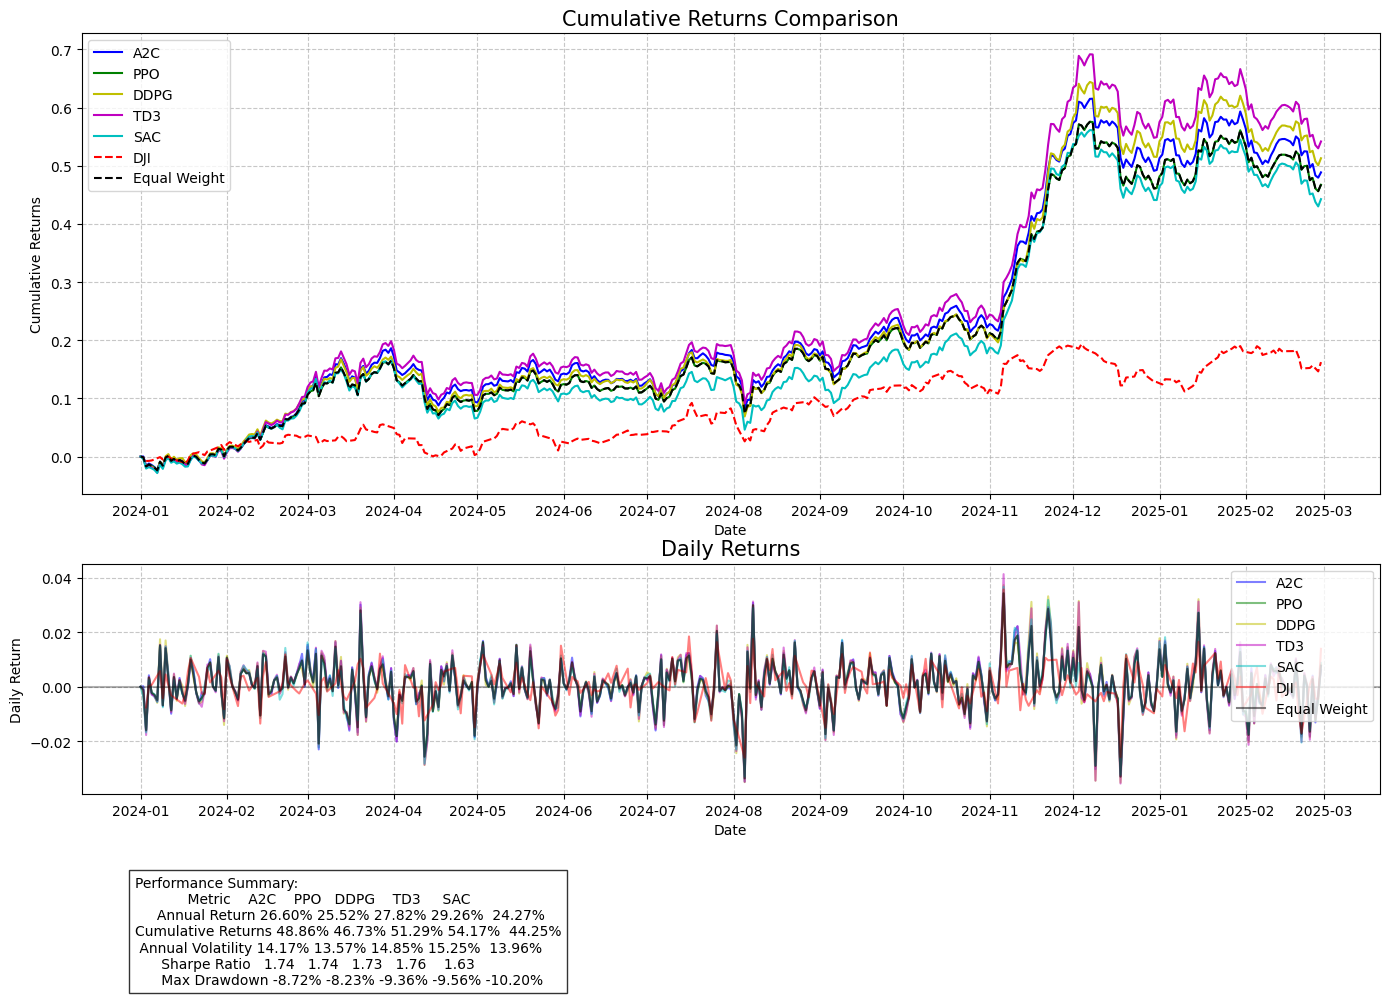

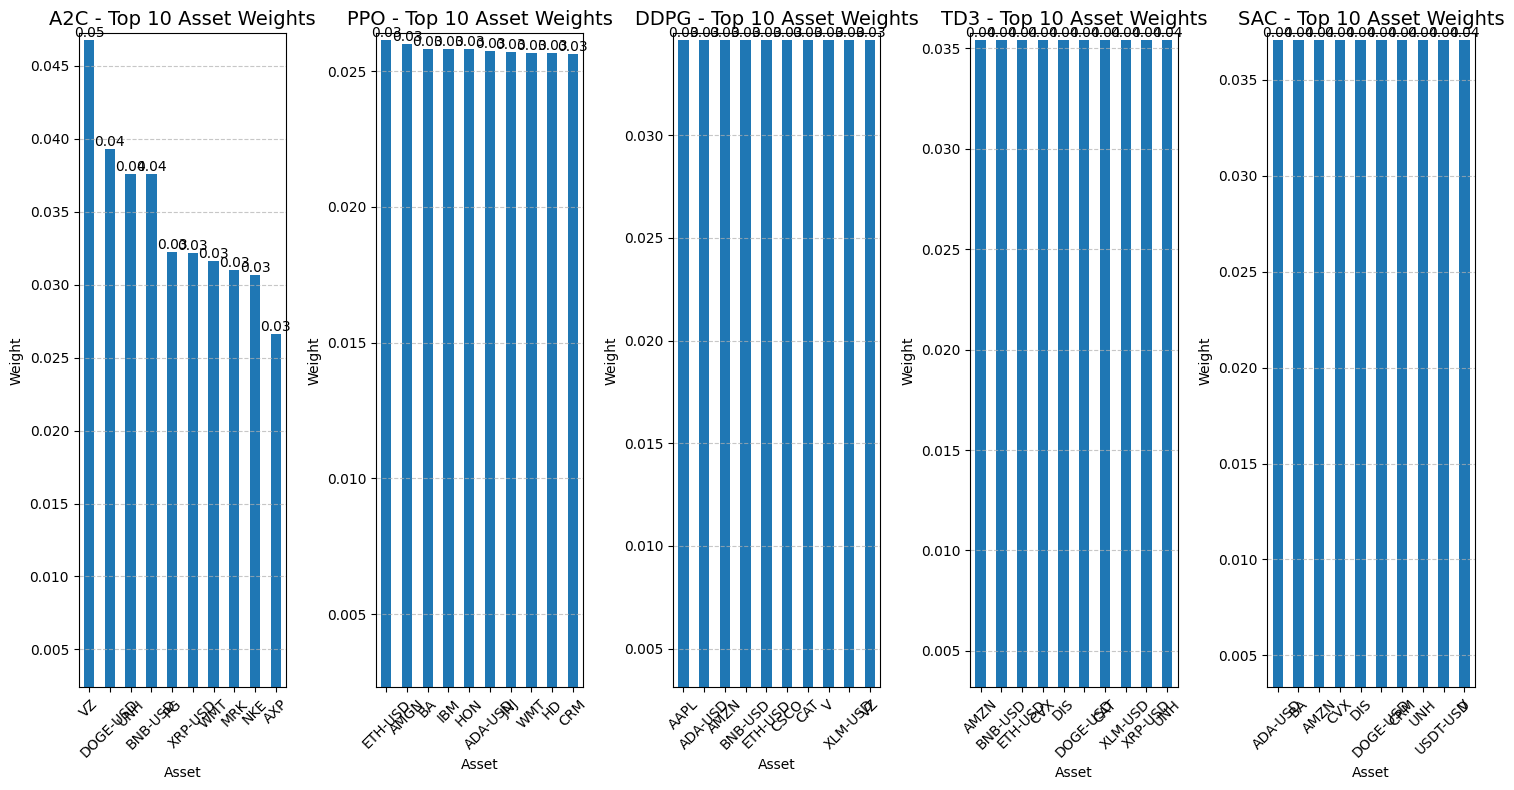

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert date strings to datetime objects
df_daily_return_a2c['date'] = pd.to_datetime(df_daily_return_a2c['date'])
df_daily_return_ppo['date'] = pd.to_datetime(df_daily_return_ppo['date'])

# Create a figure to display performance comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# Plot cumulative returns for comparison
axes[0].plot(df_daily_return_a2c['date'], a2c_cumpod, 'b-', label='A2C')
axes[0].plot(df_daily_return_ppo['date'], ppo_cumpod, 'g-', label='PPO')
axes[0].plot(df_daily_return_ddpg['date'], ddpg_cumpod, 'y-', label='DDPG')
axes[0].plot(df_daily_return_td3['date'], td3_cumpod, 'm-', label='TD3')
axes[0].plot(df_daily_return_sac['date'], sac_cumpod, 'c-', label='SAC')

# Get DJI baseline data for the test period
test_start = pd.to_datetime(TEST_START_DATE)
test_end = pd.to_datetime(TEST_END_DATE)
baseline_test = baseline_df[(pd.to_datetime(baseline_df['date']) >= test_start) & 
                           (pd.to_datetime(baseline_df['date']) <= test_end)]
print(baseline_test)
baseline_returns_test = get_daily_return(baseline_test, value_col_name="close")
baseline_cumpod_test = (baseline_returns_test + 1).cumprod() - 1

# Plot the baseline
axes[0].plot(pd.to_datetime(baseline_test['date']), baseline_cumpod_test.values, 'r--', label='DJI')
axes[0].plot(equal_weight_portfolio['date'], equal_weight_cumpod.values, 'k--', label='Equal Weight')

axes[0].set_title('Cumulative Returns Comparison', fontsize=15)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative Returns')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# Plot daily returns
axes[1].plot(df_daily_return_a2c['date'], df_daily_return_a2c['daily_return'], 'b', alpha=0.5, label='A2C')
axes[1].plot(df_daily_return_ppo['date'], df_daily_return_ppo['daily_return'], 'g', alpha=0.5, label='PPO')
axes[1].plot(df_daily_return_ddpg['date'], df_daily_return_ddpg['daily_return'], 'y', alpha=0.5, label='DDPG')
axes[1].plot(df_daily_return_td3['date'], df_daily_return_td3['daily_return'], 'm', alpha=0.5, label='TD3')
axes[1].plot(df_daily_return_sac['date'], df_daily_return_sac['daily_return'], 'c', alpha=0.5, label='SAC')
if not baseline_returns_test.empty:
    axes[1].plot(pd.to_datetime(baseline_test['date']), baseline_returns_test.values, 'r', alpha=0.5, label='DJI')
axes[1].plot(equal_weight_portfolio['date'], equal_weight_portfolio['daily_return'].values, 'k', alpha=0.5, label='Equal Weight')

axes[1].set_title('Daily Returns', fontsize=15)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Return')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# Add horizontal line at y=0 for daily returns
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Create a table with performance metrics
perf_metrics = pd.DataFrame({
    'Metric': ['Annual Return', 'Cumulative Returns', 'Annual Volatility', 'Sharpe Ratio', 'Max Drawdown'],
    'A2C': [
        f"{perf_stats_all_a2c['Annual return']:.2%}",
        f"{perf_stats_all_a2c['Cumulative returns']:.2%}",
        f"{perf_stats_all_a2c['Annual volatility']:.2%}",
        f"{perf_stats_all_a2c['Sharpe ratio']:.2f}",
        f"{perf_stats_all_a2c['Max drawdown']:.2%}"
    ],
    'PPO': [
        f"{perf_stats_all_ppo['Annual return']:.2%}",
        f"{perf_stats_all_ppo['Cumulative returns']:.2%}",
        f"{perf_stats_all_ppo['Annual volatility']:.2%}",
        f"{perf_stats_all_ppo['Sharpe ratio']:.2f}",
        f"{perf_stats_all_ppo['Max drawdown']:.2%}"
    ],
    'DDPG': [
        f"{perf_stats_all_ddpg['Annual return']:.2%}",
        f"{perf_stats_all_ddpg['Cumulative returns']:.2%}",
        f"{perf_stats_all_ddpg['Annual volatility']:.2%}",
        f"{perf_stats_all_ddpg['Sharpe ratio']:.2f}",
        f"{perf_stats_all_ddpg['Max drawdown']:.2%}"
    ],
    'TD3': [
        f"{perf_stats_all_td3['Annual return']:.2%}",
        f"{perf_stats_all_td3['Cumulative returns']:.2%}",
        f"{perf_stats_all_td3['Annual volatility']:.2%}",
        f"{perf_stats_all_td3['Sharpe ratio']:.2f}",
        f"{perf_stats_all_td3['Max drawdown']:.2%}"
    ],
    'SAC': [
        f"{perf_stats_all_sac['Annual return']:.2%}",
        f"{perf_stats_all_sac['Cumulative returns']:.2%}",
        f"{perf_stats_all_sac['Annual volatility']:.2%}",
        f"{perf_stats_all_sac['Sharpe ratio']:.2f}",
        f"{perf_stats_all_sac['Max drawdown']:.2%}"
    ]
})
perf_metrics.to_csv('portfolio_performance_comparison.csv', index=False)

# Add text with performance summary
plt.figtext(0.1, 0.01, f"Performance Summary:\n{perf_metrics.to_string(index=False)}", 
           horizontalalignment='left', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Make room for the table
plt.savefig('portfolio_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a heatmap of final portfolio weights for visualization
plt.figure(figsize=(15, 8))

# Get final weights
final_weights_a2c = df_actions_a2c.iloc[-1].sort_values(ascending=False)
final_weights_ppo = df_actions_ppo.iloc[-1].sort_values(ascending=False)
final_weights_ddpg = df_actions_ddpg.iloc[-1].sort_values(ascending=False)
final_weights_td3 = df_actions_td3.iloc[-1].sort_values(ascending=False)
final_weights_sac = df_actions_sac.iloc[-1].sort_values(ascending=False)

# Bar plot for top 10 assets by weight
top_n = 10
plt.subplot(1, 5, 1)
final_weights_a2c.head(top_n).plot(kind='bar')
for i, (index, value) in enumerate(final_weights_a2c.head(top_n).items()):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.title(f'A2C - Top {top_n} Asset Weights', fontsize=14)
plt.xlabel('Asset')
ymax = final_weights_a2c.head(top_n).max() * 1.01
ymin = final_weights_a2c.head(top_n).min() *0.09
plt.ylim(ymin, ymax)
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 5, 2)
final_weights_ppo.head(top_n).plot(kind='bar')
for i, (index, value) in enumerate(final_weights_ppo.head(top_n).items()):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.title(f'PPO - Top {top_n} Asset Weights', fontsize=14)
plt.xlabel('Asset')
ymax = final_weights_ppo.head(top_n).max() * 1.01
ymin = final_weights_ppo.head(top_n).min() *0.09
plt.ylim(ymin, ymax)
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 5, 3)
final_weights_ddpg.head(top_n).plot(kind='bar')
for i, (index, value) in enumerate(final_weights_ddpg.head(top_n).items()):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.title(f'DDPG - Top {top_n} Asset Weights', fontsize=14)
plt.xlabel('Asset')
ymax = final_weights_ddpg.head(top_n).max() * 1.01
ymin = final_weights_ddpg.head(top_n).min() *0.09
plt.ylim(ymin, ymax)
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 5, 4)
final_weights_td3.head(top_n).plot(kind='bar')
for i, (index, value) in enumerate(final_weights_td3.head(top_n).items()):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.title(f'TD3 - Top {top_n} Asset Weights', fontsize=14)
plt.xlabel('Asset')
ymax = final_weights_td3.head(top_n).max() * 1.01
ymin = final_weights_td3.head(top_n).min() *0.09
plt.ylim(ymin, ymax)
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 5, 5)
final_weights_sac.head(top_n).plot(kind='bar')
for i, (index, value) in enumerate(final_weights_sac.head(top_n).items()):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.title(f'SAC - Top {top_n} Asset Weights', fontsize=14)
plt.xlabel('Asset')
ymax = final_weights_sac.head(top_n).max() * 1.01
ymin = final_weights_sac.head(top_n).min() *0.09
plt.ylim(ymin, ymax)
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('portfolio_weights.png', dpi=300, bbox_inches='tight')
plt.show()

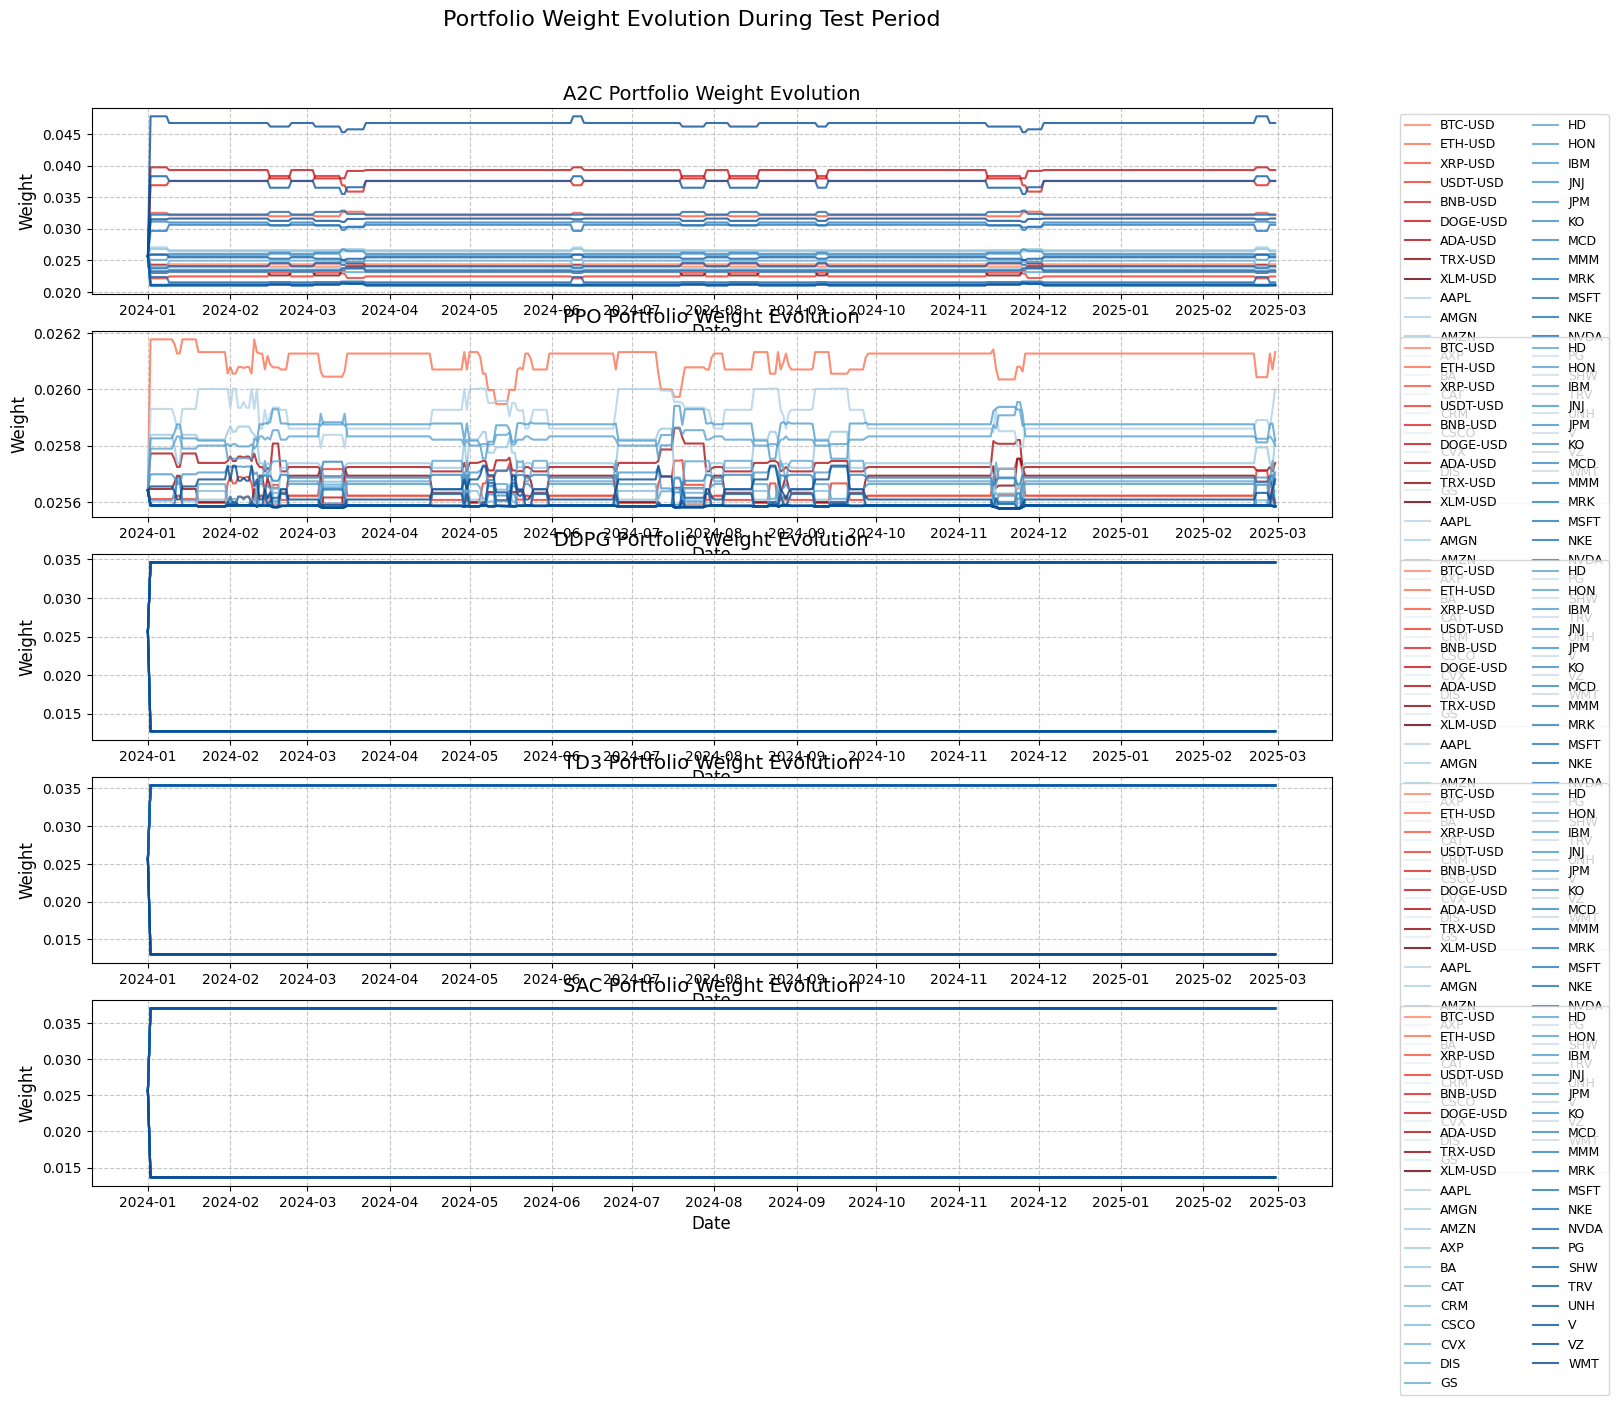

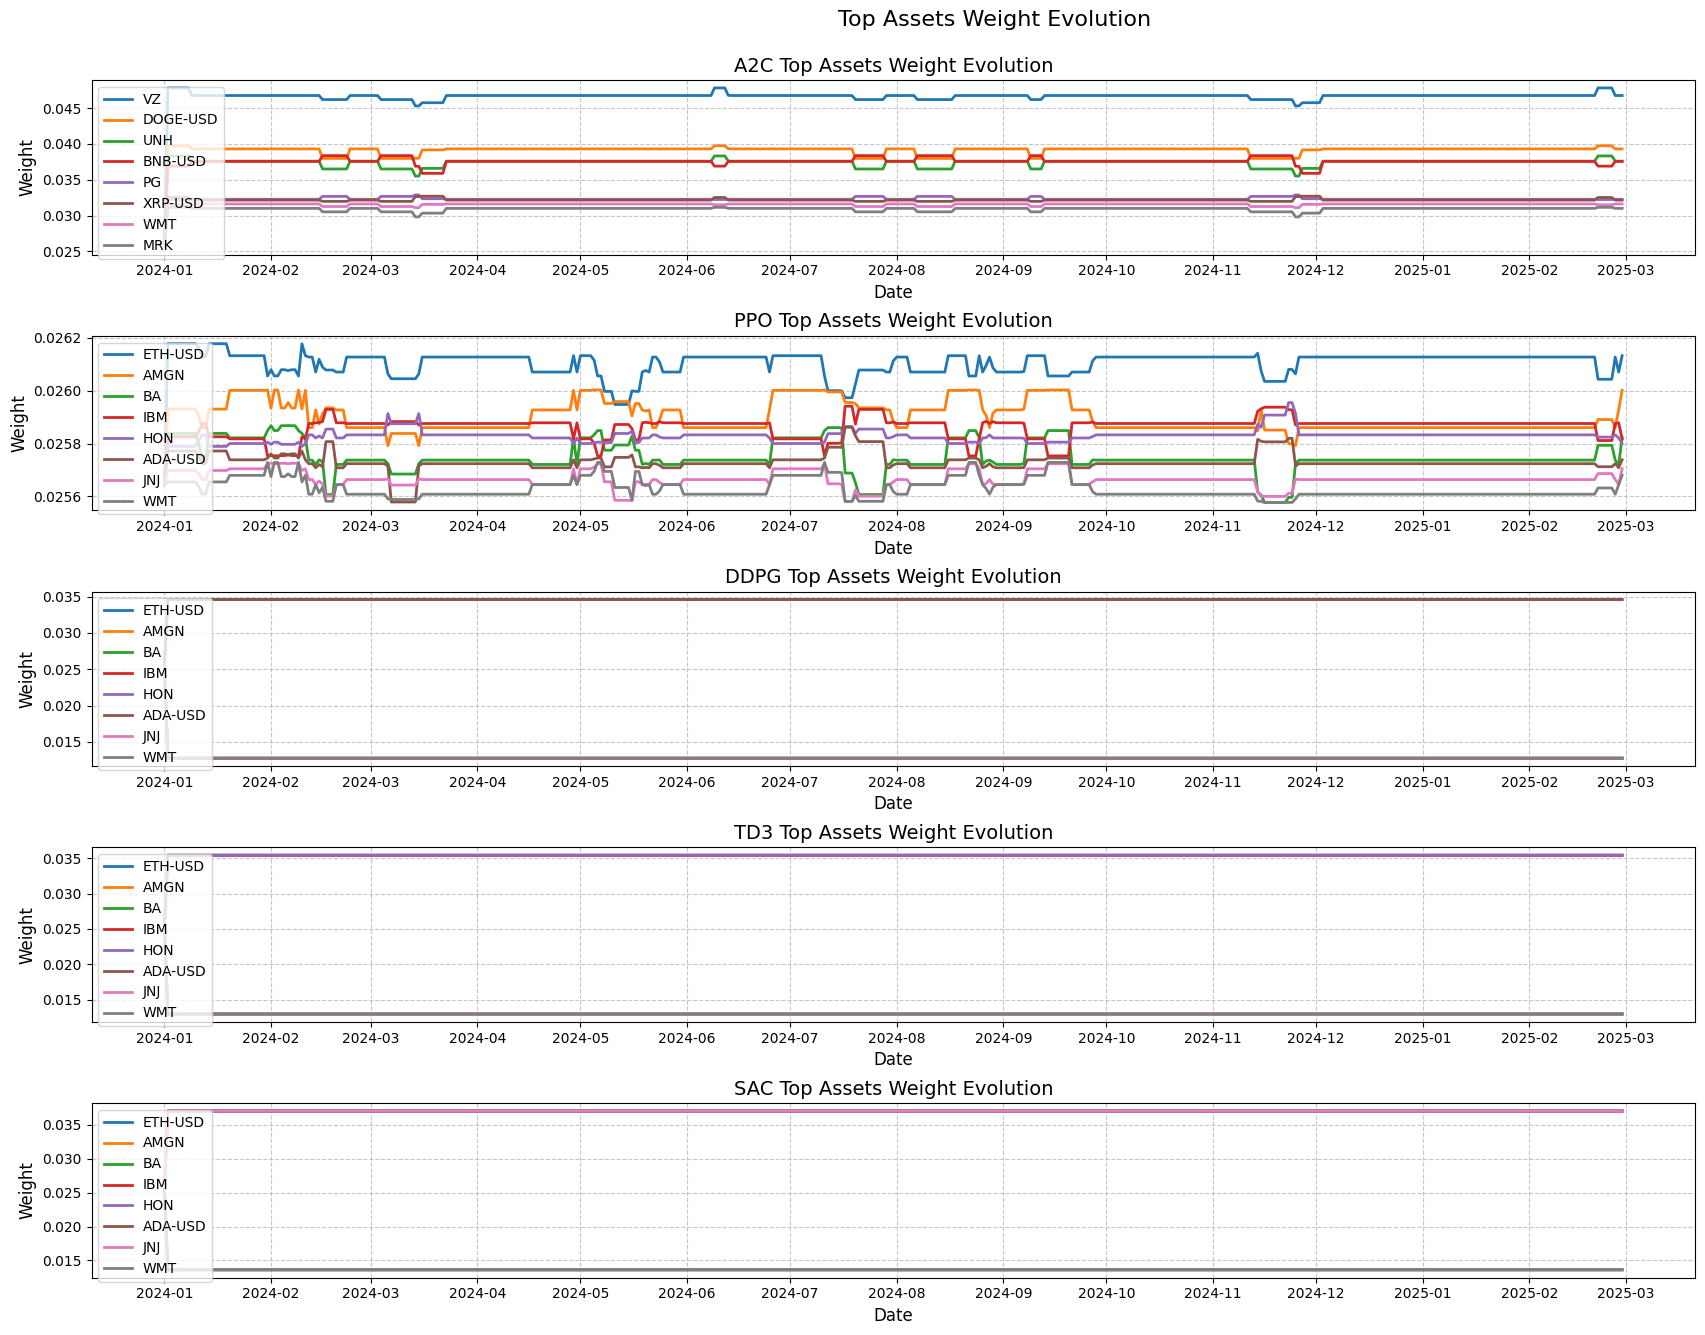


A2C - Final Portfolio Allocation by Asset Class:
Cryptocurrency allocation: 24.52%
Stock allocation: 75.48%

PPO - Final Portfolio Allocation by Asset Class:
Cryptocurrency allocation: 23.10%
Stock allocation: 76.90%

DDPG - Final Portfolio Allocation by Asset Class:
Cryptocurrency allocation: 26.78%
Stock allocation: 73.22%

TD3 - Final Portfolio Allocation by Asset Class:
Cryptocurrency allocation: 25.14%
Stock allocation: 74.86%

SAC - Final Portfolio Allocation by Asset Class:
Cryptocurrency allocation: 21.64%
Stock allocation: 78.36%

Top 5 Most Volatile Assets (A2C):
VZ: 0.00108
DOGE-USD: 0.00081
UNH: 0.00074
BNB-USD: 0.00073
PG: 0.00036

Top 5 Most Volatile Assets (PPO):
BA: 0.00006
AMGN: 0.00006
ETH-USD: 0.00005
MMM: 0.00004
IBM: 0.00004

Top 5 Most Volatile Assets (DDPG):
AMGN: 0.00063
AXP: 0.00063
BA: 0.00063
BTC-USD: 0.00063
CRM: 0.00063

Top 5 Most Volatile Assets (TD3):
AAPL: 0.00061
ADA-USD: 0.00061
AMGN: 0.00061
AXP: 0.00061
BA: 0.00061

Top 5 Most Volatile Assets (SAC)

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert dates to datetime if not already
df_actions_a2c.index = pd.to_datetime(df_actions_a2c.index)
df_actions_ppo.index = pd.to_datetime(df_actions_ppo.index)

# Set up the figure
fig, axes = plt.subplots(5, 1, figsize=(16, 14))
fig.suptitle('Portfolio Weight Evolution During Test Period', fontsize=16, y=0.95)

# Define groups - we'll separate stocks and crypto
crypto_tickers = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'USDT-USD', 'BNB-USD', 'DOGE-USD', 
                'ADA-USD', 'TRX-USD', 'XLM-USD']
stock_tickers = [col for col in df_actions_a2c.columns if col not in crypto_tickers]

# Colors for visualization
crypto_colors = plt.cm.Reds(np.linspace(0.4, 1, len(crypto_tickers)))
stock_colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(stock_tickers)))
colors_dict = {**{ticker: color for ticker, color in zip(crypto_tickers, crypto_colors)}, 
               **{ticker: color for ticker, color in zip(stock_tickers, stock_colors)}}

# Plot for A2C
axes[0].set_title('A2C Portfolio Weight Evolution', fontsize=14)
for ticker in crypto_tickers + stock_tickers:
    if ticker in df_actions_a2c.columns:
        axes[0].plot(df_actions_a2c.index, df_actions_a2c[ticker], 
                    color=colors_dict[ticker], 
                    alpha=0.8, 
                    label=ticker)

# Plot for PPO  
axes[1].set_title('PPO Portfolio Weight Evolution', fontsize=14)
for ticker in crypto_tickers + stock_tickers:
    if ticker in df_actions_ppo.columns:
        axes[1].plot(df_actions_ppo.index, df_actions_ppo[ticker], 
                    color=colors_dict[ticker], 
                    alpha=0.8, 
                    label=ticker)

# Plot for DDPG
axes[2].set_title('DDPG Portfolio Weight Evolution', fontsize=14)
for ticker in crypto_tickers + stock_tickers:
    if ticker in df_actions_ddpg.columns:
        axes[2].plot(df_actions_ddpg.index, df_actions_ddpg[ticker], 
                    color=colors_dict[ticker], 
                    alpha=0.8, 
                    label=ticker)
        
# Plot for TD3
axes[3].set_title('TD3 Portfolio Weight Evolution', fontsize=14)
for ticker in crypto_tickers + stock_tickers:
    if ticker in df_actions_td3.columns:
        axes[3].plot(df_actions_td3.index, df_actions_td3[ticker], 
                    color=colors_dict[ticker], 
                    alpha=0.8, 
                    label=ticker)
        
# Plot for SAC
axes[4].set_title('SAC Portfolio Weight Evolution', fontsize=14)
for ticker in crypto_tickers + stock_tickers:
    if ticker in df_actions_sac.columns:
        axes[4].plot(df_actions_sac.index, df_actions_sac[ticker], 
                    color=colors_dict[ticker], 
                    alpha=0.8, 
                    label=ticker)

# Format x-axis for better readability
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Weight', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=10)

# Add legends outside the plots
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
axes[3].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
axes[4].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)

# Create a separate figure to highlight top assets more clearly
fig2, axes2 = plt.subplots(5, 1, figsize=(20, 14))
fig2.suptitle('Top Assets Weight Evolution', fontsize=16, y=0.95)

# Select top 5 assets based on final weights
top_tickers_a2c = final_weights_a2c.nlargest(8).index
top_tickers_ppo = final_weights_ppo.nlargest(8).index

# Plot top assets for A2C
axes2[0].set_title('A2C Top Assets Weight Evolution', fontsize=14)
for ticker in top_tickers_a2c:
    axes2[0].plot(df_actions_a2c.index, df_actions_a2c[ticker], 
                linewidth=2, label=ticker)
    
# Plot top assets for PPO
axes2[1].set_title('PPO Top Assets Weight Evolution', fontsize=14)
for ticker in top_tickers_ppo:
    axes2[1].plot(df_actions_ppo.index, df_actions_ppo[ticker], 
                linewidth=2, label=ticker)
    
# Plot top assets for DDPG
axes2[2].set_title('DDPG Top Assets Weight Evolution', fontsize=14)
for ticker in top_tickers_ppo:
    axes2[2].plot(df_actions_ddpg.index, df_actions_ddpg[ticker], 
                linewidth=2, label=ticker)

# Plot top assets for TD3
axes2[3].set_title('TD3 Top Assets Weight Evolution', fontsize=14)
for ticker in top_tickers_ppo:
    axes2[3].plot(df_actions_td3.index, df_actions_td3[ticker], 
                linewidth=2, label=ticker)

# Plot top assets for SAC
axes2[4].set_title('SAC Top Assets Weight Evolution', fontsize=14)
for ticker in top_tickers_ppo:
    axes2[4].plot(df_actions_sac.index, df_actions_sac[ticker], 
                linewidth=2, label=ticker)


# Format for better readability
for ax in axes2:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Weight', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.9, right=0.85)
plt.show()

# Print summary of final allocations
print("\nA2C - Final Portfolio Allocation by Asset Class:")
a2c_crypto_weight = sum(final_weights_a2c[crypto_tickers])
print(f"Cryptocurrency allocation: {a2c_crypto_weight:.2%}")
print(f"Stock allocation: {1-a2c_crypto_weight:.2%}")

print("\nPPO - Final Portfolio Allocation by Asset Class:")
ppo_crypto_weight = sum(final_weights_ppo[crypto_tickers])
print(f"Cryptocurrency allocation: {ppo_crypto_weight:.2%}")
print(f"Stock allocation: {1-ppo_crypto_weight:.2%}")

print("\nDDPG - Final Portfolio Allocation by Asset Class:")
ddpg_crypto_weight = sum(final_weights_ddpg[crypto_tickers])
print(f"Cryptocurrency allocation: {ddpg_crypto_weight:.2%}")
print(f"Stock allocation: {1-ddpg_crypto_weight:.2%}")

print("\nTD3 - Final Portfolio Allocation by Asset Class:")
td3_crypto_weight = sum(final_weights_td3[crypto_tickers])
print(f"Cryptocurrency allocation: {td3_crypto_weight:.2%}")
print(f"Stock allocation: {1-td3_crypto_weight:.2%}")

print("\nSAC - Final Portfolio Allocation by Asset Class:")
sac_crypto_weight = sum(final_weights_sac[crypto_tickers])
print(f"Cryptocurrency allocation: {sac_crypto_weight:.2%}")
print(f"Stock allocation: {1-sac_crypto_weight:.2%}")

# Examine weight stability over time
a2c_weight_std = df_actions_a2c.std()
ppo_weight_std = df_actions_ppo.std()
ddpg_weight_std = df_actions_ddpg.std()
td3_weight_std = df_actions_td3.std()
sac_weight_std = df_actions_sac.std()

print("\nTop 5 Most Volatile Assets (A2C):")
for ticker, std in a2c_weight_std.nlargest(5).items():
    print(f"{ticker}: {std:.5f}")

print("\nTop 5 Most Volatile Assets (PPO):")
for ticker, std in ppo_weight_std.nlargest(5).items():
    print(f"{ticker}: {std:.5f}")

print("\nTop 5 Most Volatile Assets (DDPG):")
for ticker, std in ddpg_weight_std.nlargest(5).items():
    print(f"{ticker}: {std:.5f}")

print("\nTop 5 Most Volatile Assets (TD3):")
for ticker, std in td3_weight_std.nlargest(5).items():
    print(f"{ticker}: {std:.5f}")

print("\nTop 5 Most Volatile Assets (SAC):")
for ticker, std in sac_weight_std.nlargest(5).items():
    print(f"{ticker}: {std:.5f}")

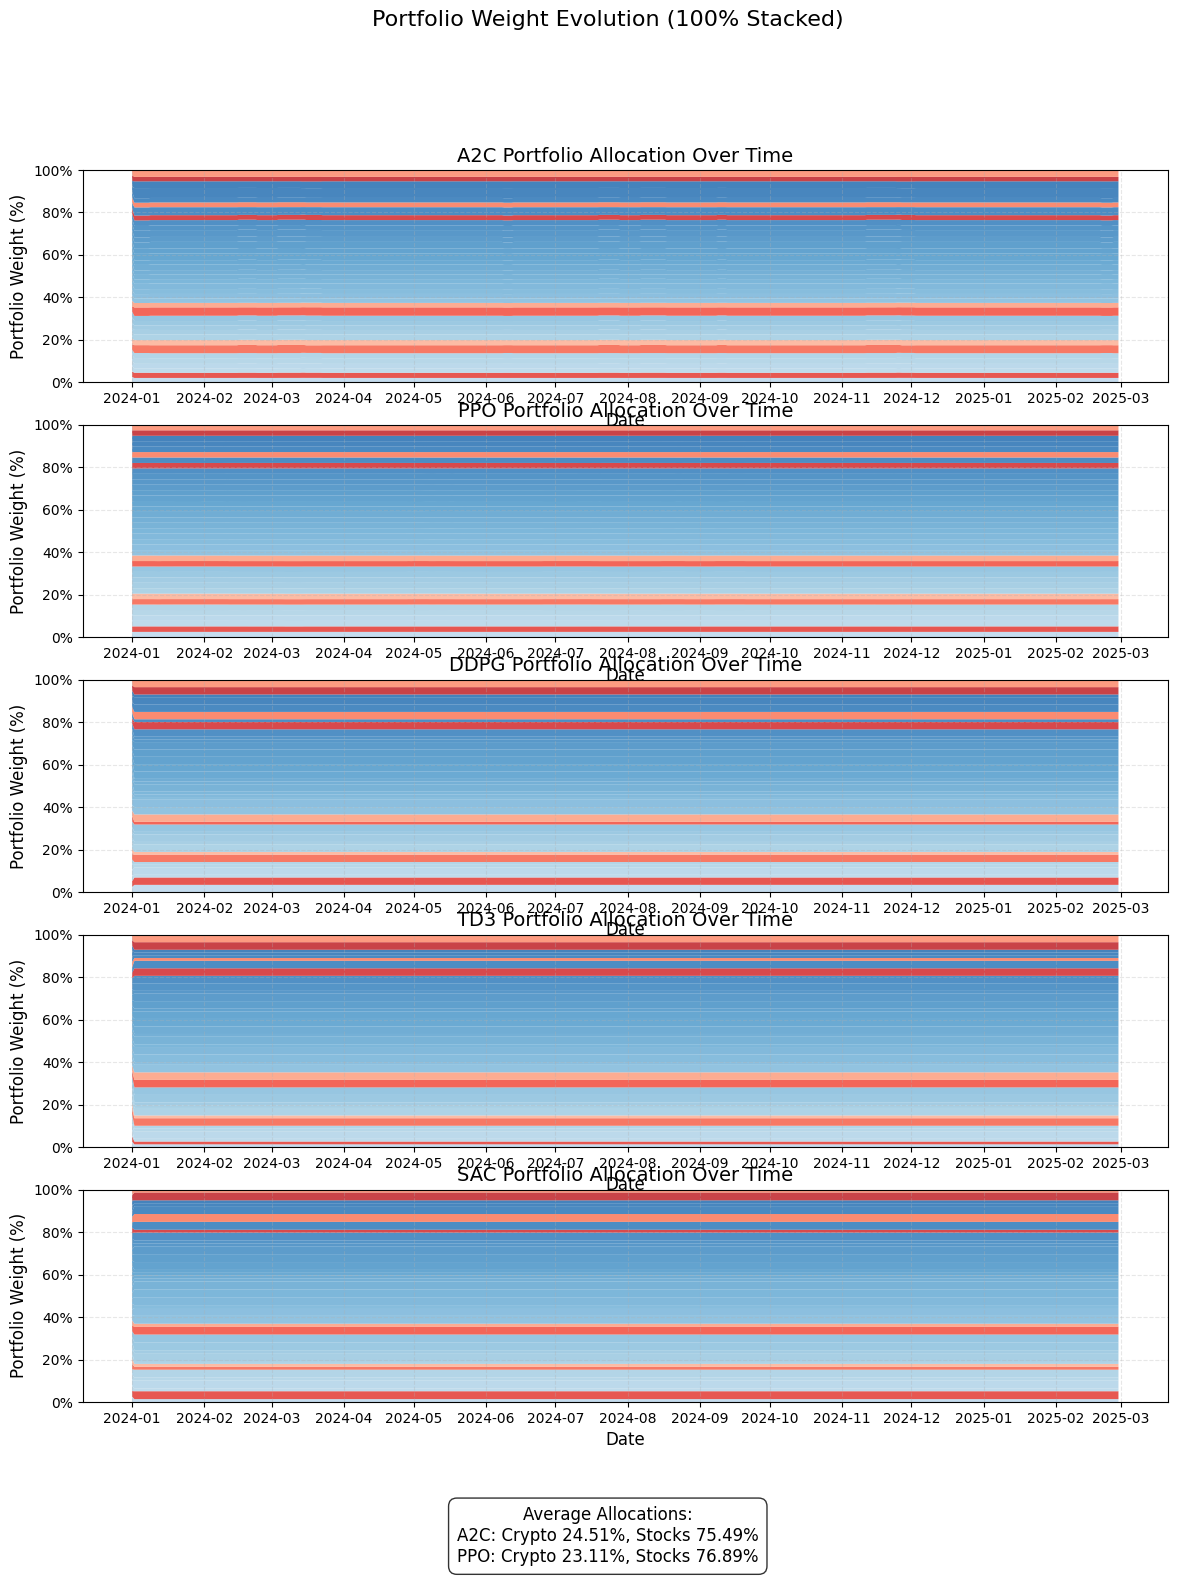

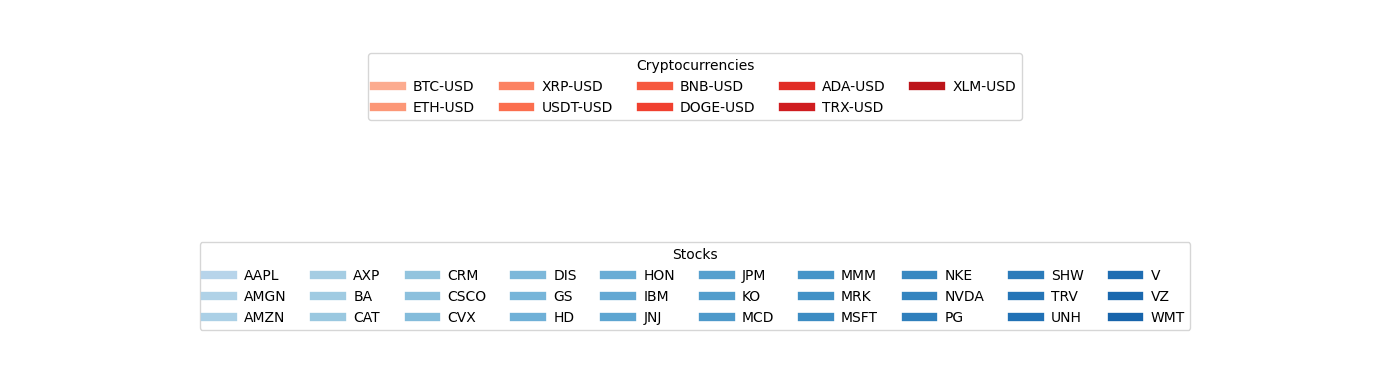

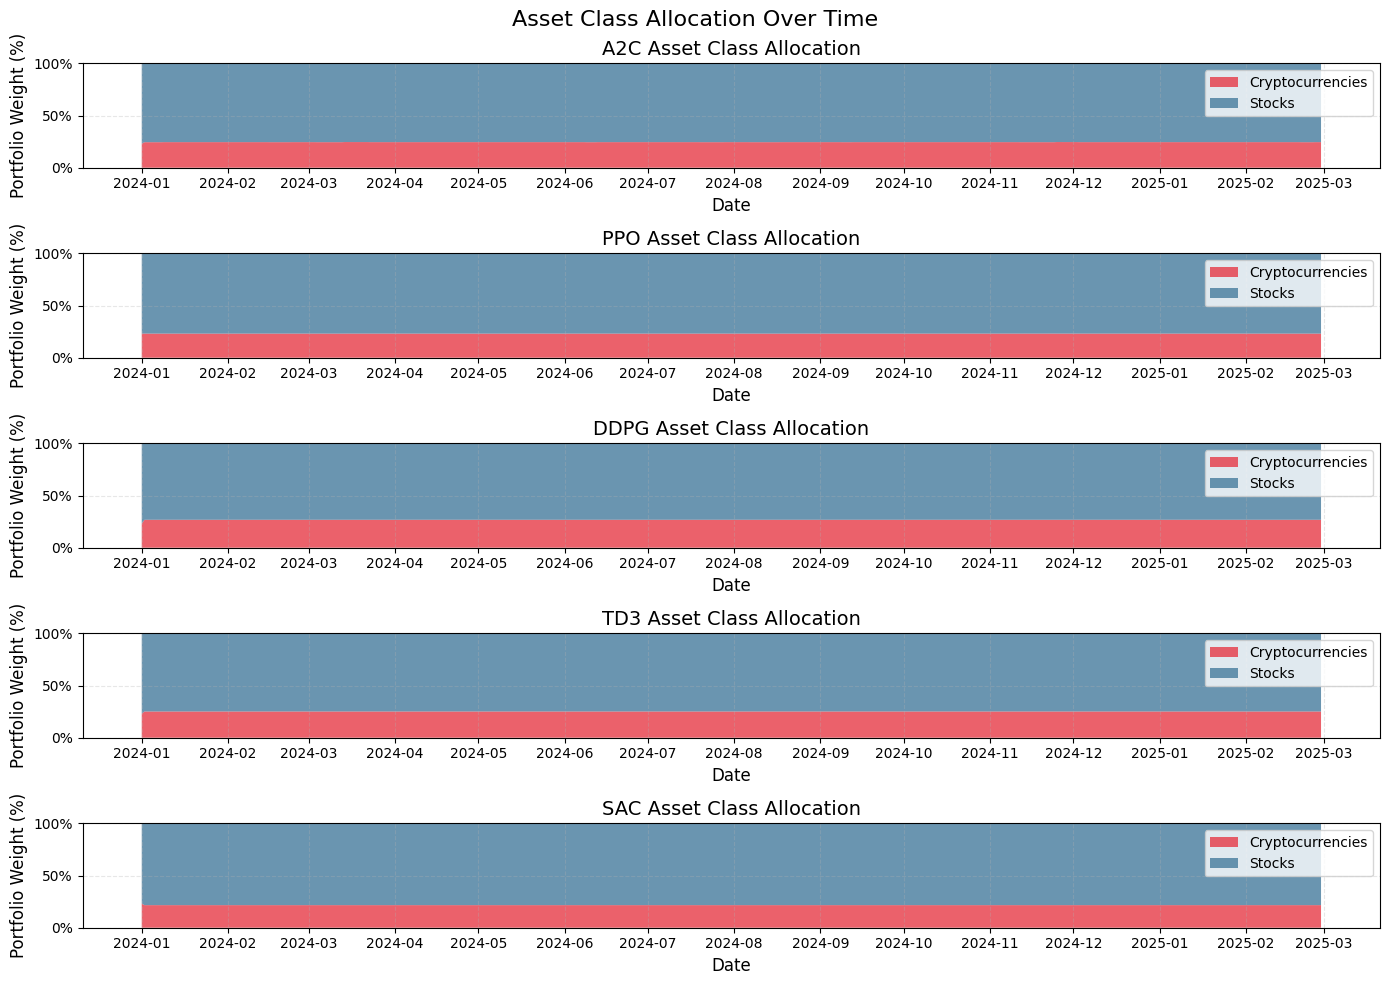

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert dates to datetime if not already
df_actions_a2c.index = pd.to_datetime(df_actions_a2c.index)
df_actions_ppo.index = pd.to_datetime(df_actions_ppo.index)
df_actions_ddpg.index = pd.to_datetime(df_actions_ddpg.index)
df_actions_td3.index = pd.to_datetime(df_actions_td3.index)
df_actions_sac.index = pd.to_datetime(df_actions_sac.index)

# Set up the figure
fig, axes = plt.subplots(5, 1, figsize=(14, 16))
fig.suptitle('Portfolio Weight Evolution (100% Stacked)', fontsize=16)

# Define groups - separate stocks and crypto for coloring
crypto_tickers = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'USDT-USD', 'BNB-USD', 'DOGE-USD', 
                 'ADA-USD', 'TRX-USD', 'XLM-USD']
stock_tickers = [col for col in df_actions_a2c.columns if col not in crypto_tickers]

# Color schemes
crypto_colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(crypto_tickers)))
stock_colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(stock_tickers)))

# Create a dictionary mapping tickers to colors
colors_dict = {}
for i, ticker in enumerate(crypto_tickers):
    colors_dict[ticker] = crypto_colors[i]
for i, ticker in enumerate(stock_tickers):
    colors_dict[ticker] = stock_colors[i]

# A2C portfolio weights stacked area plot
axes[0].stackplot(df_actions_a2c.index, 
                 [df_actions_a2c[ticker] for ticker in df_actions_a2c.columns],
                 labels=df_actions_a2c.columns,
                 colors=[colors_dict[ticker] for ticker in df_actions_a2c.columns],
                 alpha=0.8)
axes[0].set_title('A2C Portfolio Allocation Over Time', fontsize=14)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[0].grid(True, linestyle='--', alpha=0.3)

# PPO portfolio weights stacked area plot
axes[1].stackplot(df_actions_ppo.index, 
                 [df_actions_ppo[ticker] for ticker in df_actions_ppo.columns],
                 labels=df_actions_ppo.columns,
                 colors=[colors_dict[ticker] for ticker in df_actions_ppo.columns],
                 alpha=0.8)
axes[1].set_title('PPO Portfolio Allocation Over Time', fontsize=14)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[1].grid(True, linestyle='--', alpha=0.3)

# DDPG portfolio weights stacked area plot
axes[2].stackplot(df_actions_ddpg.index,
                    [df_actions_ddpg[ticker] for ticker in df_actions_ddpg.columns],
                    labels=df_actions_ddpg.columns,
                    colors=[colors_dict[ticker] for ticker in df_actions_ddpg.columns],
                    alpha=0.8)
axes[2].set_title('DDPG Portfolio Allocation Over Time', fontsize=14)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes[2].set_ylim(0, 1)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[2].grid(True, linestyle='--', alpha=0.3)

# TD3 portfolio weights stacked area plot
axes[3].stackplot(df_actions_td3.index,
                    [df_actions_td3[ticker] for ticker in df_actions_td3.columns],
                    labels=df_actions_td3.columns,
                    colors=[colors_dict[ticker] for ticker in df_actions_td3.columns],
                    alpha=0.8)
axes[3].set_title('TD3 Portfolio Allocation Over Time', fontsize=14)
axes[3].set_xlabel('Date', fontsize=12)
axes[3].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes[3].set_ylim(0, 1)
axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[3].grid(True, linestyle='--', alpha=0.3)

# SAC portfolio weights stacked area plot
axes[4].stackplot(df_actions_sac.index,
                    [df_actions_sac[ticker] for ticker in df_actions_sac.columns],
                    labels=df_actions_sac.columns,
                    colors=[colors_dict[ticker] for ticker in df_actions_sac.columns],
                    alpha=0.8)
axes[4].set_title('SAC Portfolio Allocation Over Time', fontsize=14)
axes[4].set_xlabel('Date', fontsize=12)
axes[4].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes[4].set_ylim(0, 1)
axes[4].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes[4].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[4].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[4].grid(True, linestyle='--', alpha=0.3)


# Create separate legend figures for crypto and stocks
# This makes the legend more readable
fig_legend = plt.figure(figsize=(14, 4))
gs = fig_legend.add_gridspec(2, 1)

# Crypto legend
ax1 = fig_legend.add_subplot(gs[0])
for i, ticker in enumerate(crypto_tickers):
    ax1.plot([], [], color=colors_dict[ticker], label=ticker, linewidth=6)
ax1.axis('off')
ax1.legend(loc='center', ncol=5, title='Cryptocurrencies', fontsize=10)

# Stock legend
ax2 = fig_legend.add_subplot(gs[1])
for i, ticker in enumerate(stock_tickers):
    ax2.plot([], [], color=colors_dict[ticker], label=ticker, linewidth=6)
ax2.axis('off')
ax2.legend(loc='center', ncol=10, title='Stocks', fontsize=10)

# Add summary text with allocation percentages
# Calculate average allocations
a2c_crypto_alloc = df_actions_a2c[crypto_tickers].sum(axis=1).mean()
a2c_stock_alloc = df_actions_a2c[stock_tickers].sum(axis=1).mean()
ppo_crypto_alloc = df_actions_ppo[crypto_tickers].sum(axis=1).mean()
ppo_stock_alloc = df_actions_ppo[stock_tickers].sum(axis=1).mean()

fig.text(0.5, 0.01, 
        f"Average Allocations:\nA2C: Crypto {a2c_crypto_alloc:.2%}, Stocks {a2c_stock_alloc:.2%}\nPPO: Crypto {ppo_crypto_alloc:.2%}, Stocks {ppo_stock_alloc:.2%}",
        ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.08)

# Show the plot
plt.show()

# Create simplified version showing only major asset classes
fig2, axes2 = plt.subplots(5, 1, figsize=(14, 10))
fig2.suptitle('Asset Class Allocation Over Time', fontsize=16)

# A2C - Group by asset class
a2c_crypto = df_actions_a2c[crypto_tickers].sum(axis=1)
a2c_stocks = df_actions_a2c[stock_tickers].sum(axis=1)

# PPO - Group by asset class
ppo_crypto = df_actions_ppo[crypto_tickers].sum(axis=1)
ppo_stocks = df_actions_ppo[stock_tickers].sum(axis=1)

# DDPG - Group by asset class
ddpg_crypto = df_actions_ddpg[crypto_tickers].sum(axis=1)
ddpg_stocks = df_actions_ddpg[stock_tickers].sum(axis=1)

# TD3 - Group by asset class
td3_crypto = df_actions_td3[crypto_tickers].sum(axis=1)
td3_stocks = df_actions_td3[stock_tickers].sum(axis=1)

# SAC - Group by asset class
sac_crypto = df_actions_sac[crypto_tickers].sum(axis=1)
sac_stocks = df_actions_sac[stock_tickers].sum(axis=1)

# A2C asset class stacked plot
axes2[0].stackplot(df_actions_a2c.index, 
                  [a2c_crypto, a2c_stocks],
                  labels=['Cryptocurrencies', 'Stocks'],
                  colors=['#e63946', '#457b9d'],
                  alpha=0.8)
axes2[0].set_title('A2C Asset Class Allocation', fontsize=14)
axes2[0].set_xlabel('Date', fontsize=12)
axes2[0].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes2[0].set_ylim(0, 1)
axes2[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes2[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes2[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes2[0].grid(True, linestyle='--', alpha=0.3)
axes2[0].legend(loc='upper right')

# PPO asset class stacked plot
axes2[1].stackplot(df_actions_ppo.index, 
                  [ppo_crypto, ppo_stocks],
                  labels=['Cryptocurrencies', 'Stocks'],
                  colors=['#e63946', '#457b9d'], 
                  alpha=0.8)
axes2[1].set_title('PPO Asset Class Allocation', fontsize=14)
axes2[1].set_xlabel('Date', fontsize=12)
axes2[1].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes2[1].set_ylim(0, 1)
axes2[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes2[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes2[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes2[1].grid(True, linestyle='--', alpha=0.3)
axes2[1].legend(loc='upper right')

# DDPG asset class stacked plot
axes2[2].stackplot(df_actions_ddpg.index, 
                  [ddpg_crypto, ddpg_stocks],
                  labels=['Cryptocurrencies', 'Stocks'],
                  colors=['#e63946', '#457b9d'], 
                  alpha=0.8)
axes2[2].set_title('DDPG Asset Class Allocation', fontsize=14)
axes2[2].set_xlabel('Date', fontsize=12)
axes2[2].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes2[2].set_ylim(0, 1)
axes2[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes2[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes2[2].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes2[2].grid(True, linestyle='--', alpha=0.3)
axes2[2].legend(loc='upper right')

# TD3 asset class stacked plot
axes2[3].stackplot(df_actions_td3.index, 
                  [td3_crypto, td3_stocks],
                  labels=['Cryptocurrencies', 'Stocks'],
                  colors=['#e63946', '#457b9d'], 
                  alpha=0.8)
axes2[3].set_title('TD3 Asset Class Allocation', fontsize=14)
axes2[3].set_xlabel('Date', fontsize=12)
axes2[3].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes2[3].set_ylim(0, 1)
axes2[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes2[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes2[3].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes2[3].grid(True, linestyle='--', alpha=0.3)
axes2[3].legend(loc='upper right')

# SAC asset class stacked plot
axes2[4].stackplot(df_actions_sac.index, 
                  [sac_crypto, sac_stocks],
                  labels=['Cryptocurrencies', 'Stocks'],
                  colors=['#e63946', '#457b9d'], 
                  alpha=0.8)
axes2[4].set_title('SAC Asset Class Allocation', fontsize=14)
axes2[4].set_xlabel('Date', fontsize=12)
axes2[4].set_ylabel('Portfolio Weight (%)', fontsize=12)
axes2[4].set_ylim(0, 1)
axes2[4].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
axes2[4].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes2[4].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes2[4].grid(True, linestyle='--', alpha=0.3)
axes2[4].legend(loc='upper right')

plt.tight_layout()
plt.show()
